# Installations & Imports

In [1]:
!pip install cobra -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.4 MB/s eta 0:00:00


In [2]:
import cobra

# Yeast

In [ ]:
ymodel = cobra.io.read_sbml_model("/content/yeast-GEM.xml")

In [ ]:
def sCerevisiae_anaerobic_model(model):
    # Based on the original publication's way (https://github.com/SysBioChalmers/yeast-GEM/blob/main/code/otherChanges/anaerobicModel.m)

    # Set NGAM to 0
    model.reactions.get_by_id("r_4046").lower_bound = 0
    model.reactions.get_by_id("r_4046").upper_bound = 0

    # Adjust GAM
    GAM = 30.49
    biomass_rxn = model.reactions.get_by_id("r_4041") # Biomass Psuedoreaction
    gam_mets = {
        "s_0434": -GAM,  # ATP
        "s_0803": -GAM,  # H2O
        "s_0394": GAM,   # ADP
        "s_0794": GAM,   # H+
        "s_1322": GAM,   # phosphate
    }
    for met_id, target_coeff in gam_mets.items():
        met = model.metabolites.get_by_id(met_id)
        current = biomass_rxn.metabolites.get(met, 0)
        if current != target_coeff:
            biomass_rxn.add_metabolites({met: target_coeff - current})

    # Remove O2-dependent cofactors from cofactor pseudoreaction
    # heme a, NAD, NADH, NADP+, NADPH, coenzyme A, not used anaerobically
    cofactor_rxn = model.reactions.get_by_id("r_4598")
    mets_to_remove = ['s_3714', 's_1198', 's_1203', 's_1207', 's_1212', 's_0529']
    for met_id in mets_to_remove:
        met = model.metabolites.get_by_id(met_id)
        current = cofactor_rxn.metabolites.get(met, 0)
        if current != 0:
            cofactor_rxn.add_metabolites({met: -current})  # zero it out

    # Anaerobic media
    model.reactions.get_by_id("r_1992").lower_bound = 0       # block O2
    model.reactions.get_by_id("r_1757").lower_bound = -1000   # ergosterol
    model.reactions.get_by_id("r_1915").lower_bound = -1000   # lanosterol
    model.reactions.get_by_id("r_1994").lower_bound = -1000   # palmitoleate
    model.reactions.get_by_id("r_2106").lower_bound = -1000   # zymosterol
    model.reactions.get_by_id("r_2134").lower_bound = -1000   # 14-demethyllanosterol
    model.reactions.get_by_id("r_2189").lower_bound = -1000   # oleate
    model.reactions.get_by_id("r_2137").lower_bound = -1000   # ergosta-5,7,22,24(28)-tetraen-3beta-ol

    # Block pathways
    model.reactions.get_by_id("r_0713").lower_bound = 0   # oxaloacetate-malate shuttle (Mithocondria)
    model.reactions.get_by_id("r_0714").lower_bound = 0   # oxaloacetate-malate shuttle (Cytoplasm)
    model.reactions.get_by_id("r_0487").upper_bound = 0   # glycerol dehydrogenase
    model.reactions.get_by_id("r_0472").upper_bound = 0   # alternative glutamate pathway

    return model

# Bacillus

In [ ]:
bmodel = cobra.io.read_sbml_model("/content/iBsu1147_modify.xml")

ERROR:cobra.io.sbml:'' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDD-RR' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDt6-RR' is not a valid SBML 'SId'.


In [ ]:
def bSubtilis_anaerobic_model(model):
    # Block oxygen
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0

    # Open nitrate as alternative electron acceptor
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    # Add NAD-dependent dihydroorotate dehydrogenase
    # Allows pyrimidine synthesis without O2
    # REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
    # REF: https://www.genome.jp/entry/bsu:BSU15540

    dhord_nad = cobra.Reaction("DHORDnad")
    dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
    dhord_nad.bounds = (0, 1000)
    dhord_nad.add_metabolites({
        model.metabolites.get_by_id("dhor__S_c"): -1,
        model.metabolites.get_by_id("nad_c"):    -1,
        model.metabolites.get_by_id("orot_c"):    +1,
        model.metabolites.get_by_id("nadh_c"):    +1,
        model.metabolites.get_by_id("h_c"):       +1,
    })
    model.add_reactions([dhord_nad])

    # Add aspartate dehydrogenase for anaerobic NAD+ synthesis
    # REF: https://www.kegg.jp/entry/K06989
    # REF: https://www.kegg.jp/entry/R07407

    aspdh = cobra.Reaction("ASPDH")
    aspdh.name = "Aspartate dehydrogenase (NADP-dependent)"
    aspdh.bounds = (0, 1000)
    aspdh.add_metabolites({
        model.metabolites.get_by_id("asp__L_c"): -1,
        model.metabolites.get_by_id("nadp_c"):   -1,
        model.metabolites.get_by_id("iasp_c"):   +1,
        model.metabolites.get_by_id("nadph_c"):  +1,
        model.metabolites.get_by_id("h_c"):      +1,
    })
    model.add_reactions([aspdh])

    return model

# Some Documentation & Trial and Errors (anaerobic models and old GFP/AntiGFP nanobody)

## Creating the Anaerobic Model for Bacillus (Documentation)

For Yeast i used the publication's own implementation but in python instead of matlab (https://github.com/SysBioChalmers/yeast-GEM/blob/main/code/otherChanges/anaerobicModel.m)

In [ ]:
bmodel = cobra.io.read_sbml_model("/content/iBsu1147_modify.xml")

ERROR:cobra.io.sbml:'' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDD-RR' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDt6-RR' is not a valid SBML 'SId'.


In [ ]:
model = bmodel.copy()

## First i tried to look for the Nitrate Reactions and metabolites

In [ ]:
# Search for nitrate-related reactions
for rxn in model.reactions:
    if "nitrate" in rxn.name.lower() or "nitrate" in rxn.id.lower():
        print(f"ID: {rxn.id}")
        print(f"Name: {rxn.name}")
        print(f"Equation: {rxn.reaction}")
        print(f"Bounds: ({rxn.lower_bound}, {rxn.upper_bound})")
        print("---")

# I mainly care about these two

# ID: EX_no3_e
# Name: Nitrate exchange
# Equation: no3_e -->
# Bounds: (0.0, 1000.0)

# Because this reaction basically allows the bacteria to take in nitrate (currently it is blocked so we need it open)

# ID: NTR3B
# Name: Respiratory nitrate reductase gamma chain (EC 1.7.99.4);Respiratory nitrate reductase beta chain (EC 1.7.99.4)(BSU37270);Respiratory nitrate reductase alpha chain (EC 1.7.99.4)(BSU37280);Respiratory nitrate reductase delta chain (EC 1.7.99.4)(BSU37260)
# Equation: 2.0 h_c + mql7_c + no3_c <=> h2o_c + 2.0 h_e + mqn7_c + no2_c
# Bounds: (-1000.0, 1000.0)

# And this one because this is the respiratory pathway mainly because it acts as an electron acceptor through menaquinol & menaquinone (this one is active so we are ok here)

ID: EX_no3_e
Name: Nitrate exchange
Equation: no3_e --> 
Bounds: (0.0, 1000.0)
---
ID: NTRIR2x
Name: Nitrite reductase [NAD(P)H] small subunit (EC 1.7.1.4);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03300);Assimilatory nitrate reductase large subunit (EC:1.7.99.4)(BSU03310);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03320)
Equation: 5.0 h_c + 3.0 nadh_c + no2_c --> 2.0 h2o_c + 3.0 nad_c + nh4_c
Bounds: (0.0, 1000.0)
---
ID: NTRIR2y
Name: Nitrite reductase [NAD(P)H] small subunit (EC 1.7.1.4);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03300);Assimilatory nitrate reductase large subunit (EC:1.7.99.4)(BSU03310);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03320)
Equation: 5.0 h_c + 3.0 nadph_c + no2_c --> 2.0 h2o_c + 3.0 nadp_c + nh4_c
Bounds: (0.0, 1000.0)
---
ID: NO2t2r
Name: Nitrate/nitrite transporter;Formate/nitrite family of transporters(BSU38060)
Equation: h_e + no2_e <=> h_c + no2_c
Bounds: (-1000.0, 1000.0)
---
ID: NO2t3
N

In [ ]:
for met in model.metabolites:
    if "nitrate" in met.name.lower() or "no3" in met.name.lower():
        print(f"ID: {met.id} | Name: {met.name}")

ID: no3_c | Name: Nitrate
ID: no3_e | Name: Nitrate, extracellular


## Lets activate the nitrate exchnage reaction

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0    # block oxygen
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000  # allow nitrate
    sol = model.optimize()
    print(sol.objective_value)

# the bacteria is still dead :(

-2.2455105008799007e-30


## I thought nitrate wasn't being consumed/used

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    sol = model.optimize()
    print("Growth rate:", sol.objective_value)
    print("Biomass flux:", sol.fluxes["bio00006"])
    print("Nitrate exchange flux:", sol.fluxes["EX_no3_e"])
    print("NTR3B flux:", sol.fluxes["NTR3B"])

# Growth rate: 0.0
# Biomass flux: 0.0
# Nitrate exchange flux: -1.0173913043478346
# NTR3B flux: 1.0173913043478346

# aaaand they are being consumed/used but it is still dead :(

Growth rate: 0.0
Biomass flux: 0.0
Nitrate exchange flux: -1.0173913043478346
NTR3B flux: 1.0173913043478346


## So now let's actually pull the biomass reaction and check the flux coefficinet of each and every molecule of it

In [ ]:
biomass_rxn = model.reactions.get_by_id("bio00006")
print(biomass_rxn.reaction)
print("\nMetabolites:")
for met, coeff in biomass_rxn.metabolites.items():
    print(f"  {coeff:+.4f}  {met.id} ({met.name})")

0.000206831 10fthf_c + 0.000273109 ACP_c + 0.2242 CELLWALL_c + 0.5284 PROTEIN_c + 0.005253 amp_c + 105.003 atp_c + 0.002983 ca2_c + 0.0002924 cdp_c + 0.001153 cmp_c + 0.000127618 coa_c + 0.0655 cpd11462_c + 0.076 cpd15800_c + 0.0006105 ctp_c + 0.026 dna_c + 0.003209 fe3_c + 0.0002215 gdp_c + 0.0005939 gmp_c + 0.0004883 gtp_c + 105.0 h2o_c + 0.6576 k_c + 0.0304 lpteichoic_c + 0.09474 mg2_c + 0.00014977 mql7_c + 0.01822 nad_c + 0.001053 nadp_c + 0.0002367 nadph_c + 0.0008548 ppi_c --> 0.000273109 C03688_c + 104.997 adp_c + 105.0 h_c + 104.987 pi_c

Metabolites:
  -0.0002  10fthf_c (10-Formyltetrahydrofolate)
  -0.0003  ACP_c (Acyl-carrier protein)
  -0.2242  CELLWALL_c (Cell wall of B. subtilis)
  -0.5284  PROTEIN_c (Protein)
  -0.0053  amp_c (AMP)
  -105.0030  atp_c (ATP)
  -0.0030  ca2_c (Calcium)
  -0.0003  cdp_c (CDP)
  -0.0012  cmp_c (CMP)
  -0.0001  coa_c (CoA)
  -0.0655  cpd11462_c (mRNA)
  -0.0760  cpd15800_c (Lipid composition of B. subtilis)
  -0.0006  ctp_c (CTP)
  -0.0260  dn

## tbh i didn't know what to do :D, i gave the list to Claude and it mentioned i should focus on ["nad_c", "nadp_c", "nadph_c", "coa_c", "mql7_c"] since their reactions might just be oxygen dependant

In [ ]:
def find_producing_reactions(model, met_id):
    met = model.metabolites.get_by_id(met_id)
    print(f"\n=== Producers of {met.name} ({met_id}) ===")
    for rxn in met.reactions:
        coeff = rxn.metabolites[met]
        if coeff > 0:  # this reaction produces it
            print(f"  {rxn.id}: {rxn.name}")
            print(f"  Equation: {rxn.reaction}")
            print(f"  Bounds: {rxn.bounds}")
            # Check if O2 is involved
            for r_met in rxn.metabolites:
                if "o2" in r_met.id.lower():
                    print(f"  ⚠️  USES OXYGEN: {r_met.id}")
            print()

for met_id in ["nad_c", "nadp_c", "nadph_c", "coa_c", "mql7_c"]:
    find_producing_reactions(model, met_id)


=== Producers of NAD+ (nad_c) ===
  NODOx: Flavohemoprotein (Hemoglobin-like protein) (Flavohemoglobin) (Nitric oxide dioxygenase) (EC 1.14.12.17)
  Equation: nadh_c + 2.0 no_c + 2.0 o2_c --> h_c + nad_c + 2.0 no3_c
  Bounds: (0.0, 1000.0)
  ⚠️  USES OXYGEN: o2_c

  rxn05433: Enoyl-[acyl-carrier-protein] reductase [NADH] (EC 1.3.1.9);Enoyl-[acyl-carrier-protein] reductase [FMN] (EC 1.3.1.9) homolog(BSU26800)
  Equation: 4methex2eACP_c + h_c + nadh_c --> 4methexACP_c + nad_c
  Bounds: (0.0, 1000.0)

  NMNAT: Nicotinate-nucleotide adenylyltransferase (EC 2.7.7.18)
  Equation: atp_c + nmn_c --> nad_c + ppi_c
  Bounds: (0.0, 1000.0)

  NTRIR2x: Nitrite reductase [NAD(P)H] small subunit (EC 1.7.1.4);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03300);Assimilatory nitrate reductase large subunit (EC:1.7.99.4)(BSU03310);Nitrite reductase [NAD(P)H] large subunit (EC 1.7.1.4)(BSU03320)
  Equation: 5.0 h_c + 3.0 nadh_c + no2_c --> 2.0 h2o_c + 3.0 nad_c + nh4_c
  Bounds: (0.0, 1000.

## So before touching the reactions, i thought maybe i'd check if only one of them is the actual source of death

In [ ]:
# Test which biomass metabolite is the actual bottleneck
problem_mets = ["nad_c", "nadp_c", "nadph_c", "coa_c", "mql7_c"]
biomass = model.reactions.get_by_id("bio00006")

for met_id in problem_mets:
    with bmodel as model:
        # Block O2, open nitrate
        model.reactions.get_by_id("EX_o2_e").lower_bound = 0
        model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

        # Temporarily zero out this metabolite's demand in biomass
        met = model.metabolites.get_by_id(met_id)
        current_coeff = biomass.metabolites.get(met, 0)
        biomass.add_metabolites({met: -current_coeff})  # remove it

        sol = model.optimize()
        print(f"Without {met_id} demand: growth = {sol.objective_value:.6f}")

Without nad_c demand: growth = 0.000000
Without nadp_c demand: growth = 0.000000
Without nadph_c demand: growth = 0.000000
Without coa_c demand: growth = 0.000000
Without mql7_c demand: growth = 0.000000


## What if they are all missing?

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    biomass = model.reactions.get_by_id("bio00006")
    problem_mets = ["nad_c", "nadp_c", "nadph_c", "coa_c", "mql7_c"]

    for met_id in problem_mets:
        met = model.metabolites.get_by_id(met_id)
        current_coeff = biomass.metabolites.get(met, 0)
        biomass.add_metabolites({met: -current_coeff})

    sol = model.optimize()
    print(f"Without ALL cofactor demands: growth = {sol.objective_value:.6f}")

Without ALL cofactor demands: growth = 0.000000


## Another Dead end, i tried to figure out which reactions that are biomass related are not produced anaerobically by setting them as the objective

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    biomass = model.reactions.get_by_id("bio00006")

    print("Testing producibility of each biomass component under anaerobic conditions:\n")
    for met, coeff in biomass.metabolites.items():
        if coeff < 0:  # only things the biomass CONSUMES
            # temporarily make this metabolite the objective
            with bmodel as model:
                model.objective = {
                    rxn: rxn.metabolites[met]
                    for rxn in met.reactions
                }
                sol = model.optimize(objective_sense="maximize")
                status = f"{sol.objective_value:.6f}" if sol.status == "optimal" else sol.status
                flag = "❌ STUCK" if sol.status != "optimal" or sol.objective_value < 1e-10 else "✅ OK"
                print(f"{flag}  {met.id:20s} ({met.name}): max producible = {status}")

Testing producibility of each biomass component under anaerobic conditions:

❌ STUCK  10fthf_c             (10-Formyltetrahydrofolate): max producible = 0.000000
❌ STUCK  ACP_c                (Acyl-carrier protein): max producible = 0.000000
❌ STUCK  CELLWALL_c           (Cell wall of B. subtilis): max producible = 0.000000
❌ STUCK  PROTEIN_c            (Protein): max producible = 0.000000
❌ STUCK  amp_c                (AMP): max producible = 0.000000
❌ STUCK  atp_c                (ATP): max producible = 0.000000
❌ STUCK  ca2_c                (Calcium): max producible = 0.000000
❌ STUCK  cdp_c                (CDP): max producible = 0.000000
❌ STUCK  cmp_c                (CMP): max producible = 0.000000
❌ STUCK  cpd11462_c           (mRNA): max producible = 0.000000
❌ STUCK  cpd15800_c           (Lipid composition of B. subtilis): max producible = 0.000000
❌ STUCK  ctp_c                (CTP): max producible = 0.000000
❌ STUCK  dna_c                (DNA): max producible = 0.000000
❌ STUC

## I was totally lost here, tried to check the medium and compare it between the anaerobic and aerobic one

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    print("Currently open exchange reactions (allowing IMPORT):\n")
    for rxn in model.exchanges:
        if rxn.lower_bound < 0:
            print(f"  {rxn.id:20s} lb={rxn.lower_bound:8.1f}  | {rxn.name}")

    print("\n--- Total open exchanges:",
          sum(1 for r in model.exchanges if r.lower_bound < 0))

Currently open exchange reactions (allowing IMPORT):

  EX_h2o_e             lb= -1000.0  | H2O exchange
  EX_pi_e              lb= -1000.0  | Orthophosphate exchange
  EX_co2_e             lb= -1000.0  | CO2 exchange
  EX_nh4_e             lb= -1000.0  | NH3 exchange
  EX_so4_e             lb= -1000.0  | Sulfate exchange
  EX_ca2_e             lb= -1000.0  | Calcium exchange
  EX_h_e               lb= -1000.0  | H+ exchange
  EX_k_e               lb= -1000.0  | Potassium exchange
  EX_no3_e             lb= -1000.0  | Nitrate exchange
  EX_glc__D_e          lb=    -5.0  | D-Glucose exchange
  EX_mg2_e             lb= -1000.0  | Magnesium exchange
  EX_na1_e             lb= -1000.0  | Sodium exchange
  EX_fe3_e             lb= -1000.0  | Fe3+ exchange

--- Total open exchanges: 13


In [ ]:
# On the original model with no changes
print("Open exchanges in BASE model:\n")
for rxn in model.exchanges:
    if rxn.lower_bound < 0:
        print(f"  {rxn.id:20s} lb={rxn.lower_bound:8.1f}  | {rxn.name}")

Open exchanges in BASE model:

  EX_h2o_e             lb= -1000.0  | H2O exchange
  EX_o2_e              lb= -1000.0  | Oxygen exchange
  EX_pi_e              lb= -1000.0  | Orthophosphate exchange
  EX_co2_e             lb= -1000.0  | CO2 exchange
  EX_nh4_e             lb= -1000.0  | NH3 exchange
  EX_so4_e             lb= -1000.0  | Sulfate exchange
  EX_ca2_e             lb= -1000.0  | Calcium exchange
  EX_h_e               lb= -1000.0  | H+ exchange
  EX_k_e               lb= -1000.0  | Potassium exchange
  EX_glc__D_e          lb=    -5.0  | D-Glucose exchange
  EX_mg2_e             lb= -1000.0  | Magnesium exchange
  EX_na1_e             lb= -1000.0  | Sodium exchange
  EX_fe3_e             lb= -1000.0  | Fe3+ exchange


## I tried to give all the biomass metabolites max coefficients and then drop them one by one in the anaerobic state to figure out which one kills it

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    biomass = model.reactions.get_by_id("bio00006")

    # First open ALL exchanges again
    for met, coeff in biomass.metabolites.items():
        if coeff < 0:
            ex_id = f"EX_{met.id}"
            if ex_id not in [r.id for r in model.reactions]:
                ex_rxn = cobra.Reaction(ex_id)
                ex_rxn.add_metabolites({met: 1})
                model.add_reactions([ex_rxn])
            model.reactions.get_by_id(ex_id).lower_bound = -1000

    # Now remove one at a time and check growth
    print("Removing each free import one at a time:\n")
    for met, coeff in biomass.metabolites.items():
        if coeff < 0:
            with model:
                # Close just this one exchange
                ex_id = f"EX_{met.id}"
                model.reactions.get_by_id(ex_id).lower_bound = 0

                sol = model.optimize()
                flag = "❌ KILLS GROWTH" if sol.objective_value < 1e-6 else "✅ fine"
                print(f"{flag}  {met.id:20s} ({met.name}): growth = {sol.objective_value:.6f}")

Removing each free import one at a time:

✅ fine  10fthf_c             (10-Formyltetrahydrofolate): growth = 35.659590
✅ fine  ACP_c                (Acyl-carrier protein): growth = 35.659590
✅ fine  CELLWALL_c           (Cell wall of B. subtilis): growth = 35.659590
✅ fine  PROTEIN_c            (Protein): growth = 35.659590
✅ fine  amp_c                (AMP): growth = 35.659590
✅ fine  atp_c                (ATP): growth = 35.659590
✅ fine  ca2_c                (Calcium): growth = 35.659590
✅ fine  cdp_c                (CDP): growth = 35.659590
✅ fine  cmp_c                (CMP): growth = 35.659590
✅ fine  cpd11462_c           (mRNA): growth = 35.659590
✅ fine  cpd15800_c           (Lipid composition of B. subtilis): growth = 35.659590
✅ fine  ctp_c                (CTP): growth = 35.659590
✅ fine  dna_c                (DNA): growth = 35.659590
✅ fine  fe3_c                (Fe3+): growth = 35.659590
✅ fine  gdp_c                (GDP): growth = 35.659590
✅ fine  gmp_c                (GMP)

## Something was off, growth of 35 is unrealistic, since the original aerobic model has growth of 0.39 + it seems like missing one of them didn't kill it at all

## I tried to get a FBA solution for aerobic and one for anaerobic and try to compare them and find the ones that dies out when anaerobic begins + uses oxygen

In [ ]:
sol_aero = model.optimize()
aerobic_fluxes = sol_aero.fluxes

with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000
    sol_anaero = model.optimize()
    anaerobic_fluxes = sol_anaero.fluxes

print("Reactions ACTIVE aerobically, DEAD anaerobically, using ACTUAL O2:\n")
for rxn in model.reactions:
    aero = abs(aerobic_fluxes[rxn.id])
    anaero = abs(anaerobic_fluxes[rxn.id])
    if aero > 1e-6 and anaero < 1e-10:
        # Exact match only
        uses_o2 = any(m.id == "o2_c" for m in rxn.metabolites)
        if uses_o2:
            print(f"  {rxn.id:15s} aero={aero:.4f}")
            print(f"  Equation: {rxn.reaction}")
            print()

Reactions ACTIVE aerobically, DEAD anaerobically, using ACTUAL O2:

  CAT             aero=0.0292
  Equation: 2.0 h2o2_c --> 2.0 h2o_c + o2_c

  ASPO6           aero=0.0077
  Equation: asp__L_c + o2_c --> h2o2_c + h_c + iasp_c

  DHORDfum        aero=0.0506
  Equation: dhor__S_c + o2_c --> h2o2_c + orot_c

  O2t             aero=13.4554
  Equation: o2_e <=> o2_c

  CYOO3           aero=26.8524
  Equation: 2.0 focytc_c + 6.0 h_c + 0.5 o2_c --> 2.0 ficytC_c + h2o_c + 4.0 h_e



I gave the list to Claude, here is what it said

In [ ]:
# CAT — catalase actually produces O2 from H2O2, it's not a consumer. Ignore it.
# O2t — just oxygen transport. Expected to be dead. Ignore it.
# CYOO3 — cytochrome oxidase, the aerobic ETC terminal. Expected to be dead anaerobically. Ignore it.

# That leaves two real culprits:
# ASPO6 — L-aspartate oxidase. This uses O2 to convert aspartate → iminoaspartate, which feeds directly into de novo NAD⁺ biosynthesis (the quinolinate pathway). No O2 → can't make NAD⁺ from scratch.
# DHORDfum — Dihydroorotate dehydrogenase. Uses O2 in pyrimidine biosynthesis — the pathway that makes UMP, which then becomes UTP, CTP, and all the nucleotides the cell needs for RNA and DNA.

## so then we tried to bypass each one alone and check growth and then bypass them both together once more

In [ ]:
with bmodel as model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    # Test 1: bypass ASPO6 by opening NAD import
    with bmodel as model:
        met = model.metabolites.get_by_id("nad_c")
        ex = cobra.Reaction("EX_nad_c")
        ex.add_metabolites({met: 1})
        ex.lower_bound = -1000
        model.add_reactions([ex])
        sol = model.optimize()
        print(f"With free NAD import: {sol.objective_value:.6f}")

    # Test 2: bypass DHORDfum by opening orotate import
    with bmodel as model:
        met = model.metabolites.get_by_id("orot_c")
        ex = cobra.Reaction("EX_orot_c")
        ex.add_metabolites({met: 1})
        ex.lower_bound = -1000
        model.add_reactions([ex])
        sol = model.optimize()
        print(f"With free orotate import: {sol.objective_value:.6f}")

    # Test 3: both together
    with bmodel as model:
        for met_id in ["nad_c", "orot_c"]:
            met = model.metabolites.get_by_id(met_id)
            ex = cobra.Reaction(f"EX_{met_id}")
            ex.add_metabolites({met: 1})
            ex.lower_bound = -1000
            model.add_reactions([ex])
        sol = model.optimize()
        print(f"With both free: {sol.objective_value:.6f}")

With free NAD import: 0.000000
With free orotate import: 0.000000
With both free: 0.224092


## IT GROWS :D and 0.22 is around 55%-60% of the aerobic value of 0.39 so this sounds realisitc

## Now the thing was how to have both of them active in a real biological way and not unlimited like we set them in the beggining

## First we look up the DHORD related reactions

In [ ]:
for rxn in model.reactions:
    if "DHORD" in rxn.id or "dihydroorot" in rxn.name.lower():
        print(f"{rxn.id}: {rxn.reaction}")
        print(f"  Bounds: {rxn.bounds}\n")

DHORDfum: dhor__S_c + o2_c --> h2o2_c + orot_c
  Bounds: (0.0, 1000.0)

DHORTSn: dhor__S_c + h2o_c <=> cbasp_c + h_c
  Bounds: (-1000.0, 1000.0)



In [ ]:
# Here is what Claude mentioned

#For pyrimidines — the model is genuinely missing an anaerobic reaction.
# DHORDfum is the only way to convert dihydroorotate → orotate, and it needs O2. But in real B. subtilis,
# there's a second enzyme — menaquinone-dependent DHORD — that does the exact same conversion using menaquinone instead of O2.
#  This reaction exists in the organism but is simply absent from the iBsu1147 model, This is a model gap.

## So then i looked up DHORD reactions on KEGG for B subtilis and found this reaction in B subtilis, it doesn't use menaquinones, it uses NAD and NADH, but they both serve the same function mediating the electron transports

In [ ]:
# REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
# REF: https://www.genome.jp/entry/bsu:BSU15540

dhord_nad = cobra.Reaction("DHORDnad")
dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
dhord_nad.bounds = (0, 1000)
dhord_nad.add_metabolites({
    model.metabolites.get_by_id("dhor__S_c"): -1,
    model.metabolites.get_by_id("nad_c"):    -1,
    model.metabolites.get_by_id("orot_c"):    +1,
    model.metabolites.get_by_id("nadh_c"):    +1,
    model.metabolites.get_by_id("h_c"):       +1,
})
model.add_reactions([dhord_nad])

## Then for ASPO6 which is supposed to produce iminoaspartate for the de novo NAD+ synthesis, but it oxygen dependant so i checked KEGG again and found an alternative pathways that depends on NADP as the electron acceptor instead

In [ ]:
# REF: https://www.kegg.jp/entry/K06989
# REF: https://www.kegg.jp/entry/R07407

aspdh = cobra.Reaction("ASPDH")
aspdh.name = "Aspartate dehydrogenase (NADP-dependent)"
aspdh.bounds = (0, 1000)
aspdh.add_metabolites({
    model.metabolites.get_by_id("asp__L_c"): -1,
    model.metabolites.get_by_id("nadp_c"):   -1,
    model.metabolites.get_by_id("iasp_c"):   +1,
    model.metabolites.get_by_id("nadph_c"):  +1,
    model.metabolites.get_by_id("h_c"):      +1,
})
model.add_reactions([aspdh])

## So basically these are the final model changes that we needed for the B subtilis to perform and grow on nitrate respiration

In [ ]:
def bSubtilis_anaerobic_model(model):
    # Block oxygen
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0

    # Open nitrate as alternative electron acceptor
    model.reactions.get_by_id("EX_no3_e").lower_bound = -1000

    # Add NAD-dependent dihydroorotate dehydrogenase
    # Allows pyrimidine synthesis without O2
    # REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
    # REF: https://www.genome.jp/entry/bsu:BSU15540

    dhord_nad = cobra.Reaction("DHORDnad")
    dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
    dhord_nad.bounds = (0, 1000)
    dhord_nad.add_metabolites({
        model.metabolites.get_by_id("dhor__S_c"): -1,
        model.metabolites.get_by_id("nad_c"):    -1,
        model.metabolites.get_by_id("orot_c"):    +1,
        model.metabolites.get_by_id("nadh_c"):    +1,
        model.metabolites.get_by_id("h_c"):       +1,
    })
    model.add_reactions([dhord_nad])

    # Add aspartate dehydrogenase for anaerobic NAD+ synthesis
    # REF: https://www.kegg.jp/entry/K06989
    # REF: https://www.kegg.jp/entry/R07407

    aspdh = cobra.Reaction("ASPDH")
    aspdh.name = "Aspartate dehydrogenase (NAD(P)-dependent)"
    aspdh.bounds = (0, 1000)
    aspdh.add_metabolites({
        model.metabolites.get_by_id("asp__L_c"): -1,
        model.metabolites.get_by_id("nadp_c"):   -1,
        model.metabolites.get_by_id("iasp_c"):   +1,
        model.metabolites.get_by_id("nadph_c"):  +1,
        model.metabolites.get_by_id("h_c"):      +1,
    })
    model.add_reactions([aspdh])

    return model

## Building the Nanobody Production Pipeline for Yeast (this is the old Anti-GFP nanobody - nb14 is later on)

In [ ]:
model = cobra.io.read_sbml_model("/content/yeast-GEM.xml")

In [ ]:
# Search for alanine as a test case
query = "alanine"
hits = [m for m in model.metabolites if query.lower() in m.name.lower()]

for m in hits:
    print(f"  ID: {m.id:15s} | Name: {m.name:35s} | Compartment: {m.compartment}")

  ID: s_0441          | Name: beta-alanine                        | Compartment: c
  ID: s_0955          | Name: L-alanine                           | Compartment: c
  ID: s_0956          | Name: L-alanine                           | Compartment: e
  ID: s_0957          | Name: L-alanine                           | Compartment: m
  ID: s_0987          | Name: L-gamma-glutamyl-L-alanine          | Compartment: c
  ID: s_1032          | Name: L-phenylalanine                     | Compartment: c
  ID: s_1033          | Name: L-phenylalanine                     | Compartment: e
  ID: s_1034          | Name: L-phenylalanine                     | Compartment: m
  ID: s_3759          | Name: L-alanine                           | Compartment: v
  ID: s_4104          | Name: 3-sulfino-L-alanine                 | Compartment: c
  ID: s_4105          | Name: 3-sulfino-L-alanine                 | Compartment: e
  ID: s_4296          | Name: D-phenylalanine                     | Compartment: c
  ID

In [ ]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}
missing = []

for one_letter, name in aa_names.items():
    # Find exact name match in cytoplasm
    hits = [m for m in model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]
        print(f"  ✓ {one_letter} | {hits[0].id} | {hits[0].name}")
    else:
        missing.append((one_letter, name))
        print(f"  ✗ {one_letter} | NOT FOUND | {name}")

print(f"\nFound: {len(aa_metabolites)}/20")
print(f"Missing: {missing}")

  ✓ A | s_0955 | L-alanine
  ✓ R | s_0965 | L-arginine
  ✓ N | s_0969 | L-asparagine
  ✓ D | s_0973 | L-aspartate
  ✓ C | s_0981 | L-cysteine
  ✓ Q | s_0999 | L-glutamine
  ✓ E | s_0991 | L-glutamate
  ✗ G | NOT FOUND | glycine
  ✓ H | s_1006 | L-histidine
  ✓ I | s_1016 | L-isoleucine
  ✓ L | s_1021 | L-leucine
  ✓ K | s_1025 | L-lysine
  ✓ M | s_1029 | L-methionine
  ✓ F | s_1032 | L-phenylalanine
  ✓ P | s_1035 | L-proline
  ✓ S | s_1039 | L-serine
  ✓ T | s_1045 | L-threonine
  ✓ W | s_1048 | L-tryptophan
  ✓ Y | s_1051 | L-tyrosine
  ✓ V | s_1056 | L-valine

Found: 19/20
Missing: [('G', 'glycine')]


In [ ]:
# Search for alanine as a test case
query = "glycine"
hits = [m for m in model.metabolites if query.lower() in m.name.lower()]

for m in hits:
    print(f"  ID: {m.id:15s} | Name: {m.name:35s} | Compartment: {m.compartment}")

  ID: s_0301          | Name: 5'-phosphoribosyl-N-formylglycineamide | Compartment: c
  ID: s_0302          | Name: 5'-phosphoribosyl-N-formylglycineamidine | Compartment: c
  ID: s_0325          | Name: 5-phospho-ribosyl-glycineamide      | Compartment: c
  ID: s_0960          | Name: L-alpha-formylglycine               | Compartment: c
  ID: s_0983          | Name: L-cysteinylglycine                  | Compartment: c
  ID: s_1003          | Name: L-glycine                           | Compartment: c
  ID: s_1004          | Name: L-glycine                           | Compartment: e
  ID: s_1005          | Name: L-glycine                           | Compartment: m
  ID: s_3839          | Name: L-glycine                           | Compartment: v
  ID: s_3853          | Name: R-S-Cysteinylglycine                | Compartment: c
  ID: s_3923          | Name: N-(4-oxoglutarate)-L-cysteinylglycine | Compartment: c
  ID: s_3924          | Name: N-(4-oxoglutarate)-L-cysteinylglycine | Compart

In [ ]:
# ============================================================
# YEAST9 - Amino Acid Metabolites (Cytoplasm, compartment 'c')
# ============================================================
aa_metabolites_ids = {
    'A': 's_0955',  # L-alanine
    'R': 's_0965',  # L-arginine
    'N': 's_0969',  # L-asparagine
    'D': 's_0973',  # L-aspartate
    'C': 's_0981',  # L-cysteine
    'Q': 's_0999',  # L-glutamine
    'E': 's_0991',  # L-glutamate
    'G': 's_1003',  # L-glycine
    'H': 's_1006',  # L-histidine
    'I': 's_1016',  # L-isoleucine
    'L': 's_1021',  # L-leucine
    'K': 's_1025',  # L-lysine
    'M': 's_1029',  # L-methionine
    'F': 's_1032',  # L-phenylalanine
    'P': 's_1035',  # L-proline
    'S': 's_1039',  # L-serine
    'T': 's_1045',  # L-threonine
    'W': 's_1048',  # L-tryptophan
    'Y': 's_1051',  # L-tyrosine
    'V': 's_1056',  # L-valine
}

# Now build the actual metabolite object lookup
aa_metabolites = {
    letter: model.metabolites.get_by_id(mid)
    for letter, mid in aa_metabolites_ids.items()
}

print("All 20 amino acids loaded ✓")
for letter, met in aa_metabolites.items():
    print(f"  {letter} | {met.id} | {met.name}")

All 20 amino acids loaded ✓
  A | s_0955 | L-alanine
  R | s_0965 | L-arginine
  N | s_0969 | L-asparagine
  D | s_0973 | L-aspartate
  C | s_0981 | L-cysteine
  Q | s_0999 | L-glutamine
  E | s_0991 | L-glutamate
  G | s_1003 | L-glycine
  H | s_1006 | L-histidine
  I | s_1016 | L-isoleucine
  L | s_1021 | L-leucine
  K | s_1025 | L-lysine
  M | s_1029 | L-methionine
  F | s_1032 | L-phenylalanine
  P | s_1035 | L-proline
  S | s_1039 | L-serine
  T | s_1045 | L-threonine
  W | s_1048 | L-tryptophan
  Y | s_1051 | L-tyrosine
  V | s_1056 | L-valine


In [ ]:
# Search for alanine as a test case
query = "H+"
hits = [m for m in model.metabolites if query.lower() in m.name.lower()]

for m in hits:
    print(f"  ID: {m.id:15s} | Name: {m.name:35s} | Compartment: {m.compartment}")

  ID: s_0793          | Name: H+                                  | Compartment: ce
  ID: s_0794          | Name: H+                                  | Compartment: c
  ID: s_0795          | Name: H+                                  | Compartment: er
  ID: s_0796          | Name: H+                                  | Compartment: e
  ID: s_0797          | Name: H+                                  | Compartment: g
  ID: s_0798          | Name: H+                                  | Compartment: lp
  ID: s_0799          | Name: H+                                  | Compartment: m
  ID: s_0800          | Name: H+                                  | Compartment: n
  ID: s_0801          | Name: H+                                  | Compartment: p
  ID: s_0802          | Name: H+                                  | Compartment: v
  ID: s_2783          | Name: H+                                  | Compartment: erm
  ID: s_3094          | Name: H+                                  | Compartment: m

In [ ]:
# ============================================================
# YEAST9 - Energy & Water Metabolites (Cytoplasm, compartment 'c')
# ============================================================
atp  = model.metabolites.get_by_id('s_0434')  # ATP
adp  = model.metabolites.get_by_id('s_0394')  # ADP
pi   = model.metabolites.get_by_id('s_1322')  # phosphate (Pi)
h2o  = model.metabolites.get_by_id('s_0803')  # H2O
h = model.metabolites.get_by_id('s_0794')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  s_0434 | ATP
ADP:  s_0394 | ADP
Pi:   s_1322  | phosphate
H2O:  s_0803 | H2O
H+:  s_0794 | H+


In [ ]:
from collections import Counter

# Anti-GFP VHH nanobody (Rothbauer et al.) - https://www.rcsb.org/3d-view/3K1K
NANOBODY_SEQ = (
    "MAQVQLQESGGGLVQAGGSLRLSCAASGRTFSSYAMGWFRQAPGKEREFVS"
    "AISWSGGSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAA"
    "KLLNPYWGQGTQVTVSS"
)

aa_counts = Counter(NANOBODY_SEQ)
n_aa = len(NANOBODY_SEQ)

print(f"Total amino acids: {n_aa}")
print(f"Composition: {dict(aa_counts)}")
print(f"ATP cost will be: {4 * n_aa} (4 per AA)")
print(f"Peptide bonds: {n_aa - 1} → releases {n_aa - 1} H2O")

Total amino acids: 115
Composition: {'Q': 8, 'V': 8, 'L': 8, 'E': 4, 'S': 15, 'G': 13, 'A': 11, 'R': 6, 'C': 2, 'T': 7, 'F': 4, 'Y': 7, 'M': 2, 'W': 3, 'P': 3, 'K': 5, 'I': 2, 'D': 3, 'N': 4}
ATP cost will be: 460 (4 per AA)
Peptide bonds: 114 → releases 114 H2O


In [ ]:
from cobra import Reaction, Metabolite

# ============================================================
# 3b — Create the nanobody as a pseudometabolite
# (it's a product we track but doesn't participate elsewhere)
# ============================================================

nanobody = Metabolite(
    'nanobody_vhh_c',
    name='Anti-GFP VHH Nanobody (reference)',
    compartment='c'
)

# ============================================================
# 3c — Build the synthesis reaction
# ============================================================

nanobody_rxn = Reaction('NB_SYNTH')
nanobody_rxn.name = 'Nanobody VHH Synthesis'
nanobody_rxn.lower_bound = 0      # irreversible, can only go forward
nanobody_rxn.upper_bound = 1000

stoich = {}

# CONSUMED: amino acids (negative = consumed)
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# CONSUMED: ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# CONSUMED: H2O for tRNA charging (1 per AA)
# RELEASED: H2O from peptide bonds (n_aa - 1)
# NET: -(n_aa) + (n_aa - 1) = -1
stoich[h2o] = -1

# PRODUCED: ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# PRODUCED: H+ (released during peptide bond formation)
stoich[h] = n_aa - 1

# PRODUCED: the nanobody itself
stoich[nanobody] = 1

nanobody_rxn.add_metabolites(stoich)

print("Reaction built ✓")
print(f"\nReaction ID: {nanobody_rxn.id}")
print(f"Formula preview:")
print(f"  {nanobody_rxn.reaction[:150]}")

Reaction built ✓

Reaction ID: NB_SYNTH
Formula preview:
  460 s_0434 + s_0803 + 11 s_0955 + 6 s_0965 + 4 s_0969 + 3 s_0973 + 2 s_0981 + 4 s_0991 + 8 s_0999 + 13 s_1003 + 2 s_1016 + 8 s_1021 + 5 s_1025 + 2 s_1


In [ ]:
nanobody_rxn.reaction

'460 s_0434 + s_0803 + 11 s_0955 + 6 s_0965 + 4 s_0969 + 3 s_0973 + 2 s_0981 + 4 s_0991 + 8 s_0999 + 13 s_1003 + 2 s_1016 + 8 s_1021 + 5 s_1025 + 2 s_1029 + 4 s_1032 + 3 s_1035 + 15 s_1039 + 7 s_1045 + 3 s_1048 + 7 s_1051 + 8 s_1056 --> nanobody_vhh_c + 460 s_0394 + 114 s_0794 + 460 s_1322'

In [ ]:
# ============================================================
# 3d — Demand reaction (sink for the nanobody product)
# ============================================================

nb_demand = Reaction('NB_DEMAND')
nb_demand.name = 'Nanobody Demand Sink'
nb_demand.lower_bound = 0
nb_demand.upper_bound = 1000
nb_demand.add_metabolites({nanobody: -1})

# ============================================================
# 3e — Add both reactions to the model
# ============================================================

model.add_reactions([nanobody_rxn, nb_demand])

print(f"Reactions added to model ✓")
print(f"Model now has {len(model.reactions)} reactions")

# Quick sanity check — are they in there?
print(f"\nNB_SYNTH in model: {'NB_SYNTH' in [r.id for r in model.reactions]}")
print(f"NB_DEMAND in model: {'NB_DEMAND' in [r.id for r in model.reactions]}")

Reactions added to model ✓
Model now has 4133 reactions

NB_SYNTH in model: True
NB_DEMAND in model: True


In [ ]:
# ============================================================
# Step 4a — Baseline FBA, no nanobody forced
# Prediction: growth unchanged, NB flux = 0
# ============================================================

with model:
    sol_baseline = model.optimize()
    nb_flux = sol_baseline.fluxes['NB_DEMAND']
    print(f"Baseline growth:       {sol_baseline.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {nb_flux:.6f} mmol/gDW/h")
    print(f"Status:                {sol_baseline.status}")

# ============================================================
# Step 4b — Force a tiny nanobody production, see what happens
# ============================================================

with model:
    model.reactions.get_by_id('NB_DEMAND').lower_bound = 0.001
    sol_forced = model.optimize()
    print(f"\nForced growth:         {sol_forced.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {sol_forced.fluxes['NB_DEMAND']:.6f} mmol/gDW/h")
    print(f"Status:                {sol_forced.status}")
    print(f"\nGrowth reduction:      {((sol_baseline.objective_value - sol_forced.objective_value)/sol_baseline.objective_value)*100:.4f}%")

Baseline growth:       0.0238 h⁻¹
Nanobody flux:         0.000000 mmol/gDW/h
Status:                optimal

Forced growth:         0.0090 h⁻¹
Nanobody flux:         0.001000 mmol/gDW/h
Status:                optimal

Growth reduction:      62.3222%


Max feasible nanobody flux: 0.00157 mmol/gDW/h
Growth at that point:       0.0005 h⁻¹
Total growth reduction:     98.07%
Infeasible from index:      32


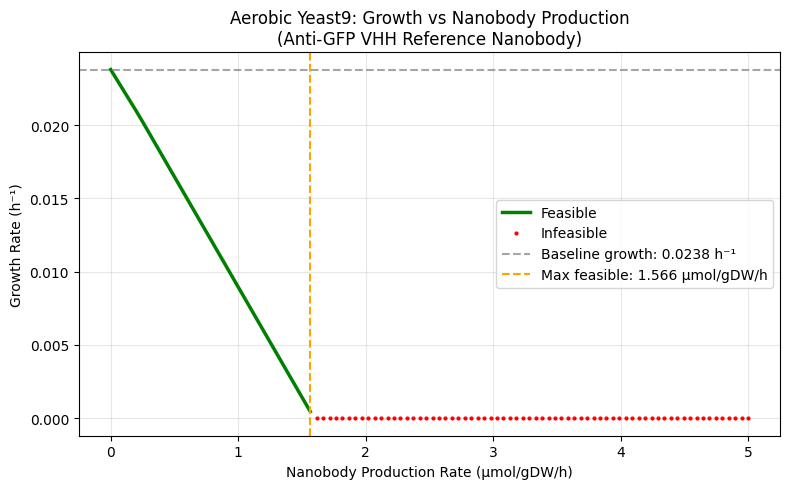

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Step 5 — Phenotypic Phase Plane
# Sweep nanobody production rate, record growth each time
# ============================================================

nb_fluxes = np.linspace(0, 0.005, 100)  # sweep from 0 to 0.005
growth_rates = []
statuses = []

for nb_flux in nb_fluxes:
    with model:
        model.reactions.get_by_id('NB_DEMAND').lower_bound = nb_flux
        sol = model.optimize()
        statuses.append(sol.status)
        if sol.status == 'optimal':
            growth_rates.append(sol.objective_value)
        else:
            growth_rates.append(0)

# Find where it becomes infeasible
feasible = [i for i, s in enumerate(statuses) if s == 'optimal']
infeasible = [i for i, s in enumerate(statuses) if s != 'optimal']

max_feasible_flux = nb_fluxes[feasible[-1]] if feasible else 0
growth_at_max = growth_rates[feasible[-1]] if feasible else 0

print(f"Max feasible nanobody flux: {max_feasible_flux:.5f} mmol/gDW/h")
print(f"Growth at that point:       {growth_at_max:.4f} h⁻¹")
print(f"Total growth reduction:     {((growth_rates[0] - growth_at_max)/growth_rates[0])*100:.2f}%")
print(f"Infeasible from index:      {infeasible[0] if infeasible else 'never'}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(nb_fluxes[feasible] * 1000,
         [growth_rates[i] for i in feasible],
         'g-', linewidth=2.5, label='Feasible')

if infeasible:
    plt.plot(nb_fluxes[infeasible] * 1000,
             [growth_rates[i] for i in infeasible],
             'r.', markersize=4, label='Infeasible')

plt.axhline(growth_rates[0], color='gray', linestyle='--',
            alpha=0.7, label=f'Baseline growth: {growth_rates[0]:.4f} h⁻¹')
plt.axvline(max_feasible_flux * 1000, color='orange', linestyle='--',
            label=f'Max feasible: {max_feasible_flux*1000:.3f} µmol/gDW/h')

plt.xlabel('Nanobody Production Rate (µmol/gDW/h)')
plt.ylabel('Growth Rate (h⁻¹)')
plt.title('Aerobic Yeast9: Growth vs Nanobody Production\n(Anti-GFP VHH Reference Nanobody)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase_plane_aerobic.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model = sCerevisiae_anaerobic_model(model)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Step 5 — Phenotypic Phase Plane
# Sweep nanobody production rate, record growth each time
# ============================================================

nb_fluxes = np.linspace(0, 0.005, 100)  # sweep from 0 to 0.005
growth_rates = []
statuses = []

for nb_flux in nb_fluxes:
    with model:
        model.reactions.get_by_id('NB_DEMAND').lower_bound = nb_flux
        sol = model.optimize()
        statuses.append(sol.status)
        if sol.status == 'optimal':
            growth_rates.append(sol.objective_value)
        else:
            growth_rates.append(0)

# Find where it becomes infeasible
feasible = [i for i, s in enumerate(statuses) if s == 'optimal']
infeasible = [i for i, s in enumerate(statuses) if s != 'optimal']

max_feasible_flux = nb_fluxes[feasible[-1]] if feasible else 0
growth_at_max = growth_rates[feasible[-1]] if feasible else 0

print(f"Max feasible nanobody flux: {max_feasible_flux:.5f} mmol/gDW/h")
print(f"Growth at that point:       {growth_at_max:.4f} h⁻¹")
print(f"Total growth reduction:     {((growth_rates[0] - growth_at_max)/growth_rates[0])*100:.2f}%")
print(f"Infeasible from index:      {infeasible[0] if infeasible else 'never'}")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(nb_fluxes[feasible] * 1000,
         [growth_rates[i] for i in feasible],
         'g-', linewidth=2.5, label='Feasible')

if infeasible:
    plt.plot(nb_fluxes[infeasible] * 1000,
             [growth_rates[i] for i in infeasible],
             'r.', markersize=4, label='Infeasible')

plt.axhline(growth_rates[0], color='gray', linestyle='--',
            alpha=0.7, label=f'Baseline growth: {growth_rates[0]:.4f} h⁻¹')
plt.axvline(max_feasible_flux * 1000, color='orange', linestyle='--',
            label=f'Max feasible: {max_feasible_flux*1000:.3f} µmol/gDW/h')

plt.xlabel('Nanobody Production Rate (µmol/gDW/h)')
plt.ylabel('Growth Rate (h⁻¹)')
plt.title('Anaerobic Yeast9: Growth vs Nanobody Production\n(Anti-GFP VHH Reference Nanobody)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase_plane_anaerobic.png', dpi=150, bbox_inches='tight')
plt.show()

# Key Takeaways (Yeast)

In [3]:
# Nb1_gbHSV
# QVQLVESGGGSVQPGGSLRLSCAASASGRLSMSGALGWYRQVQGKSRELVATITDRSSTNYADSVKGRFTISIDDAENTMYLQMNSLKPEDTGVYYCNARWRGMNVWGKGTRVTVSSTS

# Nb14
# QLQLVESGGGSVQSGGSLRLSCAASGYPESRHCMGWFRQAPGKEREGVALIDSSGRTTYADSVKGRFTISQDNAKNTLYLQMNTLKPEDTAMYYCAADFYAAATCYVSPNGRFPPFRYRGQGTQVTVSS

## Yeast9 Anaerobize Function

In [84]:
def sCerevisiae_anaerobic_model(model):
    # Based on the original publication's way (https://github.com/SysBioChalmers/yeast-GEM/blob/main/code/otherChanges/anaerobicModel.m)

    # Set NGAM to 0
    model.reactions.get_by_id("r_4046").lower_bound = 0
    model.reactions.get_by_id("r_4046").upper_bound = 0

    # Adjust GAM
    GAM = 30.49
    biomass_rxn = model.reactions.get_by_id("r_4041") # Biomass Psuedoreaction
    gam_mets = {
        "s_0434": -GAM,  # ATP
        "s_0803": -GAM,  # H2O
        "s_0394": GAM,   # ADP
        "s_0794": GAM,   # H+
        "s_1322": GAM,   # phosphate
    }
    for met_id, target_coeff in gam_mets.items():
        met = model.metabolites.get_by_id(met_id)
        current = biomass_rxn.metabolites.get(met, 0)
        if current != target_coeff:
            biomass_rxn.add_metabolites({met: target_coeff - current})

    # Remove O2-dependent cofactors from cofactor pseudoreaction
    # heme a, NAD, NADH, NADP+, NADPH, coenzyme A, not used anaerobically
    cofactor_rxn = model.reactions.get_by_id("r_4598")
    mets_to_remove = ['s_3714', 's_1198', 's_1203', 's_1207', 's_1212', 's_0529']
    for met_id in mets_to_remove:
        met = model.metabolites.get_by_id(met_id)
        current = cofactor_rxn.metabolites.get(met, 0)
        if current != 0:
            cofactor_rxn.add_metabolites({met: -current})  # zero it out

    # Anaerobic media
    model.reactions.get_by_id("r_1992").lower_bound = 0       # block O2
    model.reactions.get_by_id("r_1757").lower_bound = -1000   # ergosterol
    model.reactions.get_by_id("r_1915").lower_bound = -1000   # lanosterol
    model.reactions.get_by_id("r_1994").lower_bound = -1000   # palmitoleate
    model.reactions.get_by_id("r_2106").lower_bound = -1000   # zymosterol
    model.reactions.get_by_id("r_2134").lower_bound = -1000   # 14-demethyllanosterol
    model.reactions.get_by_id("r_2189").lower_bound = -1000   # oleate
    model.reactions.get_by_id("r_2137").lower_bound = -1000   # ergosta-5,7,22,24(28)-tetraen-3beta-ol

    # Block pathways
    model.reactions.get_by_id("r_0713").lower_bound = 0   # oxaloacetate-malate shuttle (Mithocondria)
    model.reactions.get_by_id("r_0714").lower_bound = 0   # oxaloacetate-malate shuttle (Cytoplasm)
    model.reactions.get_by_id("r_0487").upper_bound = 0   # glycerol dehydrogenase
    model.reactions.get_by_id("r_0472").upper_bound = 0   # alternative glutamate pathway

    return model

## Nb14 Nanobody Production

### Load Model

In [139]:
model = cobra.io.read_sbml_model("/content/yeast-GEM.xml")
model.reactions.r_1714.bounds = (-5,1000) # Same Glucose Uptake as Bacillus
model.reactions.get_by_id("r_1992").bounds = (-10,1000)
model.reactions.r_1808.bounds = (0,0)

### Create the Amino Acids Dictionary

In [140]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]


In [141]:
aa_metabolites_ids = {
    'A': 's_0955',  # L-alanine
    'R': 's_0965',  # L-arginine
    'N': 's_0969',  # L-asparagine
    'D': 's_0973',  # L-aspartate
    'C': 's_0981',  # L-cysteine
    'Q': 's_0999',  # L-glutamine
    'E': 's_0991',  # L-glutamate
    'G': 's_1003',  # L-glycine
    'H': 's_1006',  # L-histidine
    'I': 's_1016',  # L-isoleucine
    'L': 's_1021',  # L-leucine
    'K': 's_1025',  # L-lysine
    'M': 's_1029',  # L-methionine
    'F': 's_1032',  # L-phenylalanine
    'P': 's_1035',  # L-proline
    'S': 's_1039',  # L-serine
    'T': 's_1045',  # L-threonine
    'W': 's_1048',  # L-tryptophan
    'Y': 's_1051',  # L-tyrosine
    'V': 's_1056',  # L-valine
}

aa_metabolites = {
    letter: model.metabolites.get_by_id(mid)
    for letter, mid in aa_metabolites_ids.items()
}

print("All 20 amino acids loaded ✓")
for letter, met in aa_metabolites.items():
    print(f"  {letter} | {met.id} | {met.name}")

All 20 amino acids loaded ✓
  A | s_0955 | L-alanine
  R | s_0965 | L-arginine
  N | s_0969 | L-asparagine
  D | s_0973 | L-aspartate
  C | s_0981 | L-cysteine
  Q | s_0999 | L-glutamine
  E | s_0991 | L-glutamate
  G | s_1003 | L-glycine
  H | s_1006 | L-histidine
  I | s_1016 | L-isoleucine
  L | s_1021 | L-leucine
  K | s_1025 | L-lysine
  M | s_1029 | L-methionine
  F | s_1032 | L-phenylalanine
  P | s_1035 | L-proline
  S | s_1039 | L-serine
  T | s_1045 | L-threonine
  W | s_1048 | L-tryptophan
  Y | s_1051 | L-tyrosine
  V | s_1056 | L-valine


### Assign Variables to important molecules

In [142]:
atp  = model.metabolites.get_by_id('s_0434')  # ATP
adp  = model.metabolites.get_by_id('s_0394')  # ADP
pi   = model.metabolites.get_by_id('s_1322')  # phosphate (Pi)
h2o  = model.metabolites.get_by_id('s_0803')  # H2O
h = model.metabolites.get_by_id('s_0794')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  s_0434 | ATP
ADP:  s_0394 | ADP
Pi:   s_1322  | phosphate
H2O:  s_0803 | H2O
H+:  s_0794 | H+


### Introduce Nb14 and its synthesis reaction

In [143]:
from collections import Counter

NB14_SEQ = "QLQLVESGGGSVQSGGSLRLSCAASGYPESRHCMGWFRQAPGKEREGVALIDSSGRTTYADSVKGRFTISQDNAKNTLYLQMNTLKPEDTAMYYCAADFYAAATCYVSPNGRFPPFRYRGQGTQVTVSS"

aa_counts = Counter(NB14_SEQ)
n_aa = len(NB14_SEQ)

print(f"Total amino acids: {n_aa}")
print(f"Composition: {dict(aa_counts)}")
print(f"ATP cost will be: {4 * n_aa} (4 per AA)")
print(f"Peptide bonds: {n_aa - 1} → releases {n_aa - 1} H2O")

Total amino acids: 129
Composition: {'Q': 8, 'L': 8, 'V': 7, 'E': 5, 'S': 14, 'G': 14, 'R': 9, 'C': 4, 'A': 12, 'Y': 8, 'P': 6, 'H': 1, 'M': 3, 'W': 1, 'F': 5, 'K': 4, 'I': 2, 'D': 5, 'T': 9, 'N': 4}
ATP cost will be: 516 (4 per AA)
Peptide bonds: 128 → releases 128 H2O


In [144]:
from cobra import Reaction, Metabolite

# Create the NB1 metabolite

NB14 = Metabolite(
    'NB14',
    name='NB14 Antibody',
    compartment='c'
)

# the synthesis reaction

NB14_rxn = Reaction('NB14_SYNTH')
NB14_rxn.name = 'NB14 Synthesis'
NB14_rxn.lower_bound = 0      # irreversible, can only go forward
NB14_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O: ATP + H2O -> ADP + Pi + H+ uses 4 H2O per AA,
# each peptide bond gives 1 H2O back (n_aa - 1 bonds) -> net 3*n_aa + 1 consumed
stoich[h2o] = -(3 * n_aa + 1)

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+ (one per ATP hydrolysed)
stoich[h] = 4 * n_aa

# The NB14 itself
stoich[NB14] = 1

NB14_rxn.add_metabolites(stoich)

print(f"Reaction ID: {NB14_rxn.id}")

Reaction ID: NB14_SYNTH


In [145]:
# Demand reaction

NB14_demand = Reaction('NB14_DEMAND')
NB14_demand.name = 'NB14 Demand Sink'
NB14_demand.lower_bound = 0
NB14_demand.upper_bound = 1000
NB14_demand.add_metabolites({NB14: -1})

# Add both reactions to the model

model.add_reactions([NB14_rxn, NB14_demand])

print(f"Reactions added to model ✓")
print(f"Model now has {len(model.reactions)} reactions")

print(f"NB14_SYNTH in model: {'NB14_SYNTH' in [r.id for r in model.reactions]}")
print(f"NB14_DEMAND in model: {'NB14_DEMAND' in [r.id for r in model.reactions]}")

Reactions added to model ✓
Model now has 4133 reactions
NB14_SYNTH in model: True
NB14_DEMAND in model: True


### Baseline FBA and FBA with minimal nanobody production

In [91]:
# Baseline FBA

with model as model:
    sol_baseline = model.optimize()
    nb_flux = sol_baseline.fluxes['NB14_DEMAND']
    print(f"Baseline growth:       {sol_baseline.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {nb_flux:.6f} mmol/gDW/h")
    print(f"Status:                {sol_baseline.status}")

# Force a tiny nanobody production

with model as model:
    model.reactions.get_by_id('NB14_DEMAND').lower_bound = 0.001
    sol_forced = model.optimize()
    print(f"\nForced growth:         {sol_forced.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {sol_forced.fluxes['NB14_DEMAND']:.6f} mmol/gDW/h")
    print(f"Status:                {sol_forced.status}")
    print(f"\nGrowth reduction:      {((sol_baseline.objective_value - sol_forced.objective_value)/sol_baseline.objective_value)*100:.4f}%")

Baseline growth:       0.4091 h⁻¹
Nanobody flux:         0.000000 mmol/gDW/h
Status:                optimal

Forced growth:         0.4001 h⁻¹
Nanobody flux:         0.001000 mmol/gDW/h
Status:                optimal

Growth reduction:      2.1992%


## Generating Targets for Knockouts & Overexpressions (Yeast - Nb14)

### Knockouts

In [ ]:
model.objective = model.reactions.get_by_id('NB14_DEMAND')

In [ ]:
def analyze_nb14_flux_on_knockouts(model, threshold_x):
    """
    Performs single reaction knockouts and prints cases where NB14_DEMAND flux > threshold_x.
    """
    print(f"Scanning knockouts for NB14_DEMAND flux > {threshold_x}...")
    print("-" * 50)

    # Iterate through all reactions in the model
    for reaction in model.reactions:
        with model:
            reaction.knock_out()
            sol = model.optimize()

            if sol.status == 'optimal':
                nb14_flux = round(sol.fluxes['NB14_DEMAND'], 5)

                if nb14_flux > threshold_x:
                    print(f"Knockout: {reaction.id:15} | NB14 Flux: {nb14_flux:.5f}")
            else:
                # Infeasible or other issues usually imply 0 flux for the demand
                pass

# Example usage (uncomment and set x to run):
analyze_nb14_flux_on_knockouts(model, model.slim_optimize())

### Overexpressions

#### FSEOF Setup

In [ ]:
import os

# 1. Unzip the uploaded file
!rm -rf wwu-muenster-main
!unzip -q /content/wwu-muenster-main.zip -d /content/temp_fseof

# Handle the potential nested folder structure from GitHub/GitLab zips
extracted_folders = [f for f in os.listdir('/content/temp_fseof') if os.path.isdir(os.path.join('/content/temp_fseof', f))]
if extracted_folders:
    source_path = os.path.join('/content/temp_fseof', extracted_folders[0])
    !mv {source_path} /content/wwu-muenster-main
    !rm -rf /content/temp_fseof
else:
    !mv /content/temp_fseof /content/wwu-muenster-main

# 2. Move your model into the folder
if os.path.exists('/content/wwu-muenster-main'):
    !cp /content/yeast-GEM.xml /content/wwu-muenster-main/yeast-GEM.xml
    print('Software extracted and model successfully moved into wwu-muenster-main/')
else:
    print('Error: Extraction failed. Please ensure wwu-muenster-main.zip is in /content/')

Software extracted and model successfully moved into wwu-muenster-main/


In [ ]:
# 3. Install requirements
import os
if os.path.exists('/content/wwu-muenster-main'):
    %cd /content/wwu-muenster-main
    !pip install cobra pandas openpyxl numpy -q
    if os.path.exists('requirements.txt'):
        !pip install -r requirements.txt -q
    print('Dependencies installed.')
else:
    print('Directory /content/wwu-muenster-main not found.')

/content/wwu-muenster-main
Dependencies installed.


#### Run FSEOF


In [ ]:
# Export the Model
cobra.io.write_sbml_model(model, "yeast-GEM-NB14.xml")

In [ ]:
import cobra
import os

# 1. Save the model in memory (which has NB14_DEMAND) to a file FSEOF can read
# We ensure the model uses 'glpk' before saving
model.solver = 'glpk'
cobra.io.write_sbml_model(model, "/content/wwu-muenster-main/yeast_with_nb14.xml")

# 2. Run FSEOF
%cd /content/wwu-muenster-main

print("Running FSEOF...")
!python run_FSEOF.py yeast_with_nb14.xml r_4041 NB14_DEMAND

/content/wwu-muenster-main
Running FSEOF...
/content/wwu-muenster-main/FSEOF.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f, enforcedFluxes, y)


In [ ]:
import pandas as pd
import os

# Load the results generated by FSEOF
results_path = '/content/wwu-muenster-main/AmplificationTargets_NB14_DEMAND.xlsx'
if os.path.exists(results_path):
    df_targets = pd.read_excel(results_path)

    # Rename first column to 'reaction_id' if it's generic
    if 'Unnamed: 0' in df_targets.columns:
        df_targets.rename(columns={'Unnamed: 0': 'reaction_id'}, inplace=True)

    # Map reaction IDs to names from our model for readability
    df_targets['name'] = df_targets['reaction_id'].apply(lambda x: model.reactions.get_by_id(x).name if x in model.reactions else 'N/A')

    # Sort by 'q_slope' as identified in the notebook state
    print("Top Amplification Targets (Highest positive q_slopes):")
    display_cols = ['reaction_id', 'name', 'q_slope', 'reaction_string']
    available_cols = [c for c in display_cols if c in df_targets.columns]
    display(df_targets.sort_values(by='q_slope', ascending=False).head(20)[available_cols])
else:
    print('Results file not found. Please check the output directory.')

Top Amplification Targets (Highest positive q_slopes):


,reaction_id,name,q_slope
859,r_1110,ADP/ATP transporter,2153.406654
873,r_1125,choline transport,1967.885417
687,r_0892,phosphoglycerate kinase,1216.485892
192,r_0216,aspartate transaminase,1052.423501
1140,r_1672,carbon dioxide exchange,801.532302
1002,r_1277,water diffusion,779.025918
4072,r_4724,"polyphosphate phosphohydrolase, m",750.448668
322,r_0366,enolase,736.438532
347,r_0452,"fumarase, cytoplasmic",611.476305
621,r_0773,NADH:ubiquinone oxidoreductase,598.482574


## Nb1 Nanobody Production

### Create the Amino Acids Dictionary

In [146]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]


In [147]:
aa_metabolites_ids = {
    'A': 's_0955',  # L-alanine
    'R': 's_0965',  # L-arginine
    'N': 's_0969',  # L-asparagine
    'D': 's_0973',  # L-aspartate
    'C': 's_0981',  # L-cysteine
    'Q': 's_0999',  # L-glutamine
    'E': 's_0991',  # L-glutamate
    'G': 's_1003',  # L-glycine
    'H': 's_1006',  # L-histidine
    'I': 's_1016',  # L-isoleucine
    'L': 's_1021',  # L-leucine
    'K': 's_1025',  # L-lysine
    'M': 's_1029',  # L-methionine
    'F': 's_1032',  # L-phenylalanine
    'P': 's_1035',  # L-proline
    'S': 's_1039',  # L-serine
    'T': 's_1045',  # L-threonine
    'W': 's_1048',  # L-tryptophan
    'Y': 's_1051',  # L-tyrosine
    'V': 's_1056',  # L-valine
}

aa_metabolites = {
    letter: model.metabolites.get_by_id(mid)
    for letter, mid in aa_metabolites_ids.items()
}

print("All 20 amino acids loaded ✓")
for letter, met in aa_metabolites.items():
    print(f"  {letter} | {met.id} | {met.name}")

All 20 amino acids loaded ✓
  A | s_0955 | L-alanine
  R | s_0965 | L-arginine
  N | s_0969 | L-asparagine
  D | s_0973 | L-aspartate
  C | s_0981 | L-cysteine
  Q | s_0999 | L-glutamine
  E | s_0991 | L-glutamate
  G | s_1003 | L-glycine
  H | s_1006 | L-histidine
  I | s_1016 | L-isoleucine
  L | s_1021 | L-leucine
  K | s_1025 | L-lysine
  M | s_1029 | L-methionine
  F | s_1032 | L-phenylalanine
  P | s_1035 | L-proline
  S | s_1039 | L-serine
  T | s_1045 | L-threonine
  W | s_1048 | L-tryptophan
  Y | s_1051 | L-tyrosine
  V | s_1056 | L-valine


### Assign Variables to important molecules

In [148]:
atp  = model.metabolites.get_by_id('s_0434')  # ATP
adp  = model.metabolites.get_by_id('s_0394')  # ADP
pi   = model.metabolites.get_by_id('s_1322')  # phosphate (Pi)
h2o  = model.metabolites.get_by_id('s_0803')  # H2O
h = model.metabolites.get_by_id('s_0794')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  s_0434 | ATP
ADP:  s_0394 | ADP
Pi:   s_1322  | phosphate
H2O:  s_0803 | H2O
H+:  s_0794 | H+


### Introduce Nb1 and its synthesis reaction

In [149]:
from collections import Counter

NB1_SEQ = "QVQLVESGGGSVQPGGSLRLSCAASASGRLSMSGALGWYRQVQGKSRELVATITDRSSTNYADSVKGRFTISIDDAENTMYLQMNSLKPEDTGVYYCNARWRGMNVWGKGTRVTVSSTS"

aa_counts = Counter(NB1_SEQ)
n_aa = len(NB1_SEQ)

print(f"Total amino acids: {n_aa}")
print(f"Composition: {dict(aa_counts)}")
print(f"ATP cost will be: {4 * n_aa} (4 per AA)")
print(f"Peptide bonds: {n_aa - 1} → releases {n_aa - 1} H2O")

Total amino acids: 119
Composition: {'Q': 6, 'V': 10, 'L': 8, 'E': 4, 'S': 17, 'G': 14, 'P': 2, 'R': 9, 'C': 2, 'A': 8, 'M': 4, 'W': 3, 'Y': 5, 'K': 4, 'T': 9, 'I': 3, 'D': 5, 'N': 5, 'F': 1}
ATP cost will be: 476 (4 per AA)
Peptide bonds: 118 → releases 118 H2O


In [150]:
from cobra import Reaction, Metabolite

# Create the NB1 metabolite

NB1 = Metabolite(
    'NB1',
    name='NB1 Antibody',
    compartment='c'
)

# the synthesis reaction

NB1_rxn = Reaction('NB1_SYNTH')
NB1_rxn.name = 'NB1 Synthesis'
NB1_rxn.lower_bound = 0      # irreversible, can only go forward
NB1_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O: ATP + H2O -> ADP + Pi + H+ uses 4 H2O per AA,
# each peptide bond gives 1 H2O back (n_aa - 1 bonds) -> net 3*n_aa + 1 consumed
stoich[h2o] = -(3 * n_aa + 1)

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+ (one per ATP hydrolysed)
stoich[h] = 4 * n_aa

# The NB1 itself
stoich[NB1] = 1

NB1_rxn.add_metabolites(stoich)

print(f"Reaction ID: {NB1_rxn.id}")

Reaction ID: NB1_SYNTH


In [151]:
# Demand reaction

NB1_demand = Reaction('NB1_DEMAND')
NB1_demand.name = 'NB1 Demand Sink'
NB1_demand.lower_bound = 0
NB1_demand.upper_bound = 1000
NB1_demand.add_metabolites({NB1: -1})

# Add both reactions to the model

model.add_reactions([NB1_rxn, NB1_demand])

print(f"Reactions added to model ✓")
print(f"Model now has {len(model.reactions)} reactions")

print(f"NB1_SYNTH in model: {'NB1_SYNTH' in [r.id for r in model.reactions]}")
print(f"NB1_DEMAND in model: {'NB1_DEMAND' in [r.id for r in model.reactions]}")

Reactions added to model ✓
Model now has 4135 reactions
NB1_SYNTH in model: True
NB1_DEMAND in model: True


### Baseline FBA and FBA with minimal nanobody production

In [ ]:
# Baseline FBA

with model as model:
    sol_baseline = model.optimize()
    nb_flux = sol_baseline.fluxes['NB1_DEMAND']
    print(f"Baseline growth:       {sol_baseline.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {nb_flux:.6f} mmol/gDW/h")
    print(f"Status:                {sol_baseline.status}")

# Force a tiny nanobody production

with model as model:
    model.reactions.get_by_id('NB1_DEMAND').lower_bound = 0.001
    sol_forced = model.optimize()
    print(f"\nForced growth:         {sol_forced.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {sol_forced.fluxes['NB1_DEMAND']:.6f} mmol/gDW/h")
    print(f"Status:                {sol_forced.status}")
    print(f"\nGrowth reduction:      {((sol_baseline.objective_value - sol_forced.objective_value)/sol_baseline.objective_value)*100:.4f}%")

Baseline growth:       0.0858 h⁻¹
Nanobody flux:         0.000000 mmol/gDW/h
Status:                optimal

Forced growth:         0.0748 h⁻¹
Nanobody flux:         0.001000 mmol/gDW/h
Status:                optimal

Growth reduction:      12.8691%


Glu (-5, 1000)
O2 (-10, 1000)
Glu (-5, 1000)
O2 (0, 1000)
Calculating max production for Yeast (Aerobic vs Anaerobic)...


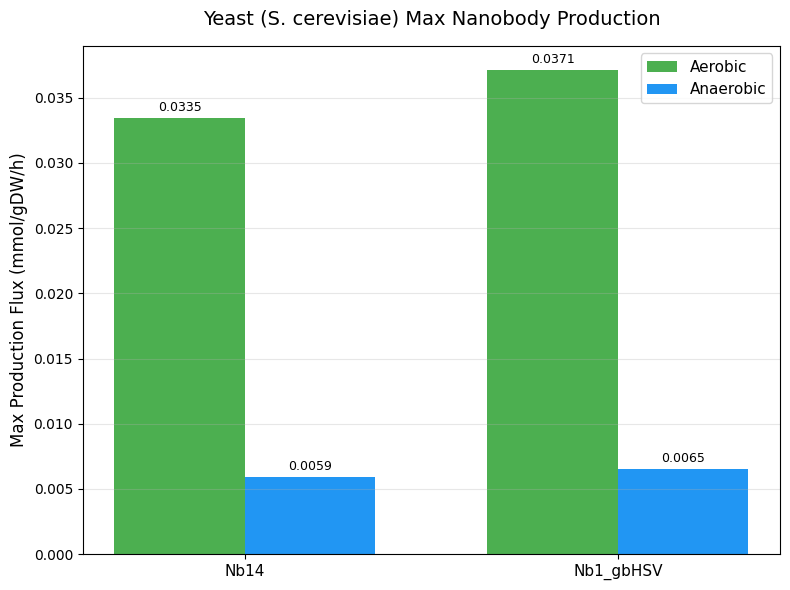

In [152]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the base yeast model
# (Assumes 'ymodel' exists; falls back to 'model' if not)
yeast_model = model.copy()

print(f"Glu {yeast_model.reactions.r_1714.bounds}")
print(f"O2 {yeast_model.reactions.get_by_id("r_1992").bounds}")

# 2. Automatically find all Nanobody demand reactions
nb_rxns = [rxn.id for rxn in yeast_model.reactions if 'NB' in rxn.id and 'DEMAND' in rxn.id]

if not nb_rxns:
    print("⚠️ No nanobody demand reactions found in the yeast model.")
    print("Please make sure you have added them to 'ymodel' (or 'model') before running this cell.")
else:
    # 3. Create the anaerobic counterpart
    yeast_anaerobic = sCerevisiae_anaerobic_model(yeast_model.copy())
    print(f"Glu {yeast_anaerobic.reactions.r_1714.bounds}")
    print(f"O2 {yeast_anaerobic.reactions.get_by_id("r_1992").bounds}")

    aerobic_fluxes = []
    anaerobic_fluxes = []

    print("Calculating max production for Yeast (Aerobic vs Anaerobic)...")
    for rxn_id in nb_rxns:
        # Aerobic
        with yeast_model as m_aero:
            m_aero.objective = rxn_id
            sol_aero = m_aero.optimize()
            val_aero = sol_aero.objective_value if sol_aero.status == 'optimal' and sol_aero.objective_value else 0.0
            aerobic_fluxes.append(val_aero)

        # Anaerobic
        with yeast_anaerobic as m_anaero:
            m_anaero.objective = rxn_id
            sol_anaero = m_anaero.optimize()
            val_anaero = sol_anaero.objective_value if sol_anaero.status == 'optimal' and sol_anaero.objective_value else 0.0
            anaerobic_fluxes.append(val_anaero)

    # 4. Plot the results side-by-side
    x = np.arange(len(nb_rxns))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, aerobic_fluxes, width, label='Aerobic', color='#4CAF50')
    rects2 = ax.bar(x + width/2, anaerobic_fluxes, width, label='Anaerobic', color='#2196F3')

    # Mapping to correct the display names
    label_map = {
        'NB1': 'Nb1_gbHSV',
        'NB14': 'Nb14'
    }

    # Generate labels, falling back to the raw name if not in the dictionary
    labels = [label_map.get(rxn.replace('_DEMAND', ''), rxn.replace('_DEMAND', '')) for rxn in nb_rxns]

    ax.set_ylabel('Max Production Flux (mmol/gDW/h)', fontsize=12)
    ax.set_title('Yeast (S. cerevisiae) Max Nanobody Production', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars with exact values
    for rect in rects1 + rects2:
        height = rect.get_height()
        if height > 1e-6:
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## Generating Targets for Knockouts & Overexpressions (Yeast - Nb1)

### Knockouts

In [ ]:
model.objective = model.reactions.get_by_id('NB1_DEMAND')

In [ ]:
def analyze_nb1_flux_on_knockouts(model, threshold_x):
    """
    Performs single reaction knockouts and prints cases where NB1_DEMAND flux > threshold_x.
    """
    print(f"Scanning knockouts for NB1_DEMAND flux > {threshold_x}...")
    print("-" * 50)

    # Iterate through all reactions in the model
    for reaction in model.reactions:
        with model:
            reaction.knock_out()
            sol = model.optimize()

            if sol.status == 'optimal':
                nb1_flux = round(sol.fluxes['NB1_DEMAND'], 5)

                if nb1_flux > threshold_x:
                    print(f"Knockout: {reaction.id:15} | NB1 Flux: {nb1_flux:.5f}")
            else:
                # Infeasible or other issues usually imply 0 flux for the demand
                pass

# Example usage (uncomment and set x to run):
analyze_nb1_flux_on_knockouts(model, model.slim_optimize())

Scanning knockouts for NB1_DEMAND flux > 0.0075791461724874715...
--------------------------------------------------
Knockout: r_0001          | NB1 Flux: 0.00758
Knockout: r_0002          | NB1 Flux: 0.00758
Knockout: r_0003          | NB1 Flux: 0.00758
Knockout: r_0004          | NB1 Flux: 0.00758
Knockout: r_0005          | NB1 Flux: 0.00758
Knockout: r_0006          | NB1 Flux: 0.00758
Knockout: r_0007          | NB1 Flux: 0.00758
Knockout: r_0012          | NB1 Flux: 0.00758
Knockout: r_0013          | NB1 Flux: 0.00758
Knockout: r_0014          | NB1 Flux: 0.00758
Knockout: r_0015          | NB1 Flux: 0.00758
Knockout: r_0017          | NB1 Flux: 0.00758
Knockout: r_0019          | NB1 Flux: 0.00758
Knockout: r_0021          | NB1 Flux: 0.00758
Knockout: r_0022          | NB1 Flux: 0.00758
Knockout: r_0024          | NB1 Flux: 0.00758
Knockout: r_0026          | NB1 Flux: 0.00758
Knockout: r_0028          | NB1 Flux: 0.00758
Knockout: r_0030          | NB1 Flux: 0.00758
Knockout:

KeyboardInterrupt: 

### Overexpressions

#### FSEOF Setup

In [ ]:
import os

# 1. Unzip the uploaded file
!rm -rf wwu-muenster-main
!unzip -q /content/wwu-muenster-main.zip -d /content/temp_fseof

# Handle the potential nested folder structure from GitHub/GitLab zips
extracted_folders = [f for f in os.listdir('/content/temp_fseof') if os.path.isdir(os.path.join('/content/temp_fseof', f))]
if extracted_folders:
    source_path = os.path.join('/content/temp_fseof', extracted_folders[0])
    !mv {source_path} /content/wwu-muenster-main
    !rm -rf /content/temp_fseof
else:
    !mv /content/temp_fseof /content/wwu-muenster-main

# 2. Move your model into the folder
if os.path.exists('/content/wwu-muenster-main'):
    !cp /content/yeast-GEM.xml /content/wwu-muenster-main/yeast-GEM.xml
    print('Software extracted and model successfully moved into wwu-muenster-main/')
else:
    print('Error: Extraction failed. Please ensure wwu-muenster-main.zip is in /content/')

Software extracted and model successfully moved into wwu-muenster-main/


In [ ]:
# 3. Install requirements
import os
if os.path.exists('/content/wwu-muenster-main'):
    %cd /content/wwu-muenster-main
    !pip install cobra pandas openpyxl numpy -q
    if os.path.exists('requirements.txt'):
        !pip install -r requirements.txt -q
    print('Dependencies installed.')
else:
    print('Directory /content/wwu-muenster-main not found.')

/content/wwu-muenster-main
Dependencies installed.


#### Run FSEOF


In [ ]:
# Export the Model
cobra.io.write_sbml_model(model, "yeast-GEM-NB1.xml")

In [ ]:
import cobra
import os

# 1. Save the model in memory (which has NB1_DEMAND) to a file FSEOF can read
# We ensure the model uses 'glpk' before saving
model.solver = 'glpk'
cobra.io.write_sbml_model(model, "/content/wwu-muenster-main/yeast_with_nb1.xml")

# 2. Run FSEOF
%cd /content/wwu-muenster-main

print("Running FSEOF...")
!python run_FSEOF.py yeast_with_nb1.xml r_4041 NB1_DEMAND

/content/wwu-muenster-main
Running FSEOF...
/content/wwu-muenster-main/FSEOF.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f, enforcedFluxes, y)


In [ ]:
import pandas as pd
import os

# Load the results generated by FSEOF
results_path = '/content/wwu-muenster-main/AmplificationTargets_NB1_DEMAND.xlsx'
if os.path.exists(results_path):
    df_targets = pd.read_excel(results_path)

    # Rename first column to 'reaction_id' if it's generic
    if 'Unnamed: 0' in df_targets.columns:
        df_targets.rename(columns={'Unnamed: 0': 'reaction_id'}, inplace=True)

    # Map reaction IDs to names from our model for readability
    df_targets['name'] = df_targets['reaction_id'].apply(lambda x: model.reactions.get_by_id(x).name if x in model.reactions else 'N/A')

    # Sort by 'q_slope' as identified in the notebook state
    print("Top Amplification Targets (Highest positive q_slopes):")
    display_cols = ['reaction_id', 'name', 'q_slope', 'reaction_string']
    available_cols = [c for c in display_cols if c in df_targets.columns]
    display(df_targets.sort_values(by='q_slope', ascending=False).head(20)[available_cols])
else:
    print('Results file not found. Please check the output directory.')

Top Amplification Targets (Highest positive q_slopes):


,reaction_id,name,q_slope
694,r_0907,phosphopentomutase,306.794119
335,r_0439,ubiquinol:ferricytochrome c reductase,269.095899
722,r_0951,inosine phosphorylase,220.098908
119,r_0140,adenosine deaminase,220.098908
1282,r_1841,hypoxanthine exchange,220.098908
1369,r_1932,mannan transport,214.951715
399,r_0511,glycogen phosphorylase,205.514039
3671,r_4316,"Dol-P-Man:Man(7)GlcNAc(2)-PP-Dol alpha-1,6-man...",199.897987
3669,r_4314,"Alpha-1,2-mannosyltransferase ALG9 (EC 2.4.1.2...",199.897987
618,r_0770,"NADH dehydrogenase, cytosolic/mitochondrial",195.111897


In [ ]:
# Now we need to filter the overexpression candidates to remove any exchange reactions or non-changeable ones like ATPM and the original nanobody demand reactions

# Key Takeaways (Bacillus)

In [ ]:
# Nb1_gbHSV
# QVQLVESGGGSVQPGGSLRLSCAASASGRLSMSGALGWYRQVQGKSRELVATITDRSSTNYADSVKGRFTISIDDAENTMYLQMNSLKPEDTGVYYCNARWRGMNVWGKGTRVTVSSTS

# Nb14
# QLQLVESGGGSVQSGGSLRLSCAASGYPESRHCMGWFRQAPGKEREGVALIDSSGRTTYADSVKGRFTISQDNAKNTLYLQMNTLKPEDTAMYYCAADFYAAATCYVSPNGRFPPFRYRGQGTQVTVSS

## Bacillus Anaerobize Function

In [123]:
def bSubtilis_anaerobic_model(model):
    # Block oxygen
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0

    # Open nitrate as alternative electron acceptor
    model.reactions.get_by_id("EX_no3_e").lower_bound = -10

    # Add NAD-dependent dihydroorotate dehydrogenase
    # Allows pyrimidine synthesis without O2
    # REF: https://www.genome.jp/dbget-bin/www_bget?ec:1.3.1.14
    # REF: https://www.genome.jp/entry/bsu:BSU15540

    dhord_nad = cobra.Reaction("DHORDnad")
    dhord_nad.name = "Dihydroorotate dehydrogenase (NAD)"
    dhord_nad.bounds = (0, 1000)
    dhord_nad.add_metabolites({
        model.metabolites.get_by_id("dhor__S_c"): -1,
        model.metabolites.get_by_id("nad_c"):    -1,
        model.metabolites.get_by_id("orot_c"):    +1,
        model.metabolites.get_by_id("nadh_c"):    +1,
        model.metabolites.get_by_id("h_c"):       +1,
    })
    model.add_reactions([dhord_nad])

    # Add aspartate dehydrogenase for anaerobic NAD+ synthesis
    # REF: https://www.kegg.jp/entry/K06989
    # REF: https://www.kegg.jp/entry/R07407

    asp = model.metabolites.get_by_id("asp__L_c")
    iasp = model.metabolites.get_by_id("iasp_c")
    fum = model.metabolites.get_by_id("fum_c")
    succ = model.metabolites.get_by_id("succ_c")

    ASPOfum = cobra.Reaction("ASPOfum")
    ASPOfum.name = "L-aspartate oxidase, fumarate-linked (NadB, BSU27870)"
    ASPOfum.bounds = (0, 1000)
    ASPOfum.add_metabolites({asp: -1, fum: -1, iasp: 1, succ: 1})
    model.add_reactions([ASPOfum])

    return model

## Nb14 Nanobody Production

### Load Model

In [153]:
model = cobra.io.read_sbml_model("/content/iBsu1147_modify.xml")
model.reactions.get_by_id("EX_o2_e").bounds = (-10,1000)

ERROR:cobra.io.sbml:'' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDD-RR' is not a valid SBML 'SId'.
ERROR:cobra.io.sbml:'R_BTDt6-RR' is not a valid SBML 'SId'.


### Create the Amino Acids Dictionary

In [154]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]

In [155]:
# Mapping of amino acid single letters to their likely IDs in the iBsu1147 model
aa_metabolites_ids = {
    'A': 'ala__L_c', 'R': 'arg__L_c', 'N': 'asn__L_c', 'D': 'asp__L_c',
    'C': 'cys__L_c', 'Q': 'gln__L_c', 'E': 'glu__L_c', 'G': 'gly_c',
    'H': 'his__L_c', 'I': 'ile__L_c', 'L': 'leu__L_c', 'K': 'lys__L_c',
    'M': 'met__L_c', 'F': 'phe__L_c', 'P': 'pro__L_c', 'S': 'ser__L_c',
    'T': 'thr__L_c', 'W': 'trp__L_c', 'Y': 'tyr__L_c', 'V': 'val__L_c'
}

aa_metabolites = {}
for letter, mid in aa_metabolites_ids.items():
    try:
        aa_metabolites[letter] = model.metabolites.get_by_id(mid)
    except KeyError:
        # Fallback: try searching by name if the standard ID doesn't work
        name_to_search = aa_names[letter].lower()
        hits = [m for m in model.metabolites if m.name.lower() == name_to_search and m.compartment == 'c']
        if hits:
            aa_metabolites[letter] = hits[0]
        else:
          print(f"Warning: No metabolite found for {letter} ({name_to_search})")

print(f"Loaded {len(aa_metabolites)}/20 amino acids.")
for letter, met in sorted(aa_metabolites.items()):
    print(f"  {letter} | {met.id} | {met.name}")

Loaded 20/20 amino acids.
  A | ala__L_c | L-Alanine
  C | cys__L_c | L-Cysteine
  D | asp__L_c | L-Aspartate
  E | glu__L_c | L-Glutamate
  F | phe__L_c | L-Phenylalanine
  G | gly_c | Glycine
  H | his__L_c | L-Histidine
  I | ile__L_c | L-Isoleucine
  K | lys__L_c | L-Lysine
  L | leu__L_c | L-Leucine
  M | met__L_c | L-Methionine
  N | asn__L_c | L-Asparagine
  P | pro__L_c | L-Proline
  Q | gln__L_c | L-Glutamine
  R | arg__L_c | L-Arginine
  S | ser__L_c | L-Serine
  T | thr__L_c | L-Threonine
  V | val__L_c | L-Valine
  W | trp__L_c | L-Tryptophan
  Y | tyr__L_c | L-Tyrosine


### Assign Variables to important molecules

In [156]:
atp  = model.metabolites.get_by_id('atp_c')  # ATP
adp  = model.metabolites.get_by_id('adp_c')  # ADP
pi   = model.metabolites.get_by_id('pi_c')   # phosphate (Pi)
h2o  = model.metabolites.get_by_id('h2o_c')  # H2O
h = model.metabolites.get_by_id('h_c')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  atp_c | ATP
ADP:  adp_c | ADP
Pi:   pi_c  | Orthophosphate
H2O:  h2o_c | H2O
H+:  h_c | H+


### Introduce Nb14 and its synthesis reaction

In [157]:
from collections import Counter

NB14_SEQ = "QLQLVESGGGSVQSGGSLRLSCAASGYPESRHCMGWFRQAPGKEREGVALIDSSGRTTYADSVKGRFTISQDNAKNTLYLQMNTLKPEDTAMYYCAADFYAAATCYVSPNGRFPPFRYRGQGTQVTVSS"

aa_counts = Counter(NB14_SEQ)
n_aa = len(NB14_SEQ)

print(f"Total amino acids: {n_aa}")
print(f"Composition: {dict(aa_counts)}")
print(f"ATP cost will be: {4 * n_aa} (4 per AA)")
print(f"Peptide bonds: {n_aa - 1} → releases {n_aa - 1} H2O")

Total amino acids: 129
Composition: {'Q': 8, 'L': 8, 'V': 7, 'E': 5, 'S': 14, 'G': 14, 'R': 9, 'C': 4, 'A': 12, 'Y': 8, 'P': 6, 'H': 1, 'M': 3, 'W': 1, 'F': 5, 'K': 4, 'I': 2, 'D': 5, 'T': 9, 'N': 4}
ATP cost will be: 516 (4 per AA)
Peptide bonds: 128 → releases 128 H2O


In [158]:
from cobra import Reaction, Metabolite

# Create the NB1 metabolite

NB14 = Metabolite(
    'NB14',
    name='NB14 Antibody',
    compartment='c'
)

# the synthesis reaction

NB14_rxn = Reaction('NB14_SYNTH')
NB14_rxn.name = 'NB14 Synthesis'
NB14_rxn.lower_bound = 0      # irreversible, can only go forward
NB14_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O: ATP + H2O -> ADP + Pi + H+ uses 4 H2O per AA,
# each peptide bond gives 1 H2O back (n_aa - 1 bonds) -> net 3*n_aa + 1 consumed
stoich[h2o] = -(3 * n_aa + 1)

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+ (one per ATP hydrolysed)
stoich[h] = 4 * n_aa

# The NB14 itself
stoich[NB14] = 1

NB14_rxn.add_metabolites(stoich)

print(f"Reaction ID: {NB14_rxn.id}")

Reaction ID: NB14_SYNTH


In [159]:
# Demand reaction

NB14_demand = Reaction('NB14_DEMAND')
NB14_demand.name = 'NB14 Demand Sink'
NB14_demand.lower_bound = 0
NB14_demand.upper_bound = 1000
NB14_demand.add_metabolites({NB14: -1})

# Add both reactions to the model

model.add_reactions([NB14_rxn, NB14_demand])

print(f"Reactions added to model ✓")
print(f"Model now has {len(model.reactions)} reactions")

print(f"NB14_SYNTH in model: {'NB14_SYNTH' in [r.id for r in model.reactions]}")
print(f"NB14_DEMAND in model: {'NB14_DEMAND' in [r.id for r in model.reactions]}")

Reactions added to model ✓
Model now has 1738 reactions
NB14_SYNTH in model: True
NB14_DEMAND in model: True


### Baseline FBA and FBA with minimal nanobody production

In [81]:
# Baseline FBA

with model as model:
    sol_baseline = model.optimize()
    nb_flux = sol_baseline.fluxes['NB14_DEMAND']
    print(f"Baseline growth:       {sol_baseline.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {nb_flux:.6f} mmol/gDW/h")
    print(f"Status:                {sol_baseline.status}")

# Force a tiny nanobody production

with model as model:
    model.reactions.get_by_id('NB14_DEMAND').lower_bound = 0.001
    sol_forced = model.optimize()
    print(f"\nForced growth:         {sol_forced.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {sol_forced.fluxes['NB14_DEMAND']:.6f} mmol/gDW/h")
    print(f"Status:                {sol_forced.status}")
    print(f"\nGrowth reduction:      {((sol_baseline.objective_value - sol_forced.objective_value)/sol_baseline.objective_value)*100:.4f}%")

Baseline growth:       0.3487 h⁻¹
Nanobody flux:         0.000000 mmol/gDW/h
Status:                optimal

Forced growth:         0.3424 h⁻¹
Nanobody flux:         0.001000 mmol/gDW/h
Status:                optimal

Growth reduction:      1.8299%


## Generating Targets for Knockouts & Overexpressions (Bacillus - Nb14)

### Knockouts

In [ ]:
model.objective = model.reactions.get_by_id('NB14_DEMAND')

In [ ]:
def analyze_nb14_flux_on_knockouts(model, threshold_x):
    """
    Performs single reaction knockouts and prints cases where NB14_DEMAND flux > threshold_x.
    """
    print(f"Scanning knockouts for NB14_DEMAND flux > {threshold_x}...")
    print("-" * 50)

    # Iterate through all reactions in the model
    for reaction in model.reactions:
        with model:
            reaction.knock_out()
            sol = model.optimize()

            if sol.status == 'optimal':
                nb14_flux = round(sol.fluxes['NB14_DEMAND'], 5)

                if nb14_flux > threshold_x:
                    print(f"Knockout: {reaction.id:15} | NB14 Flux: {nb14_flux:.5f}")
            else:
                # Infeasible or other issues usually imply 0 flux for the demand
                pass

# Example usage (uncomment and set x to run):
analyze_nb14_flux_on_knockouts(model, model.slim_optimize())

Scanning knockouts for NB14_DEMAND flux > 0.0381...
--------------------------------------------------
Knockout: ATPM            | NB14 Flux: 0.03994


KeyboardInterrupt: 

### Overexpressions

#### FSEOF Setup

In [ ]:
import os

# 1. Unzip the uploaded file
!rm -rf wwu-muenster-main
!unzip -q /content/wwu-muenster-main.zip -d /content/temp_fseof

# Handle the potential nested folder structure from GitHub/GitLab zips
extracted_folders = [f for f in os.listdir('/content/temp_fseof') if os.path.isdir(os.path.join('/content/temp_fseof', f))]
if extracted_folders:
    source_path = os.path.join('/content/temp_fseof', extracted_folders[0])
    !mv {source_path} /content/wwu-muenster-main
    !rm -rf /content/temp_fseof
else:
    !mv /content/temp_fseof /content/wwu-muenster-main

# 2. Move your model into the folder
if os.path.exists('/content/wwu-muenster-main'):
    !cp /content/yeast-GEM.xml /content/wwu-muenster-main/yeast-GEM.xml
    print('Software extracted and model successfully moved into wwu-muenster-main/')
else:
    print('Error: Extraction failed. Please ensure wwu-muenster-main.zip is in /content/')

Software extracted and model successfully moved into wwu-muenster-main/


In [ ]:
# 3. Install requirements
import os
if os.path.exists('/content/wwu-muenster-main'):
    %cd /content/wwu-muenster-main
    !pip install cobra pandas openpyxl numpy -q
    if os.path.exists('requirements.txt'):
        !pip install -r requirements.txt -q
    print('Dependencies installed.')
else:
    print('Directory /content/wwu-muenster-main not found.')

/content/wwu-muenster-main
Dependencies installed.


#### Run FSEOF


In [ ]:
# Export the Model
cobra.io.write_sbml_model(model, "bacillus-GEM-NB14.xml")

##### CLAUDE: Patch: fix `curve_fit` crash in `FSEOF.py` for sparse/draft models

**Problem:** `getSlopes()` fits a line to each reaction's flux across the FSEOF scan steps.
On models with many blocked/dead-end reactions (flux = 0 at every step), the fit line is
flat → `curve_fit` has no gradient to work with → `RuntimeError`, which crashes the whole
`.apply()` loop since it runs once per reaction.

**Fix:** skip the fit if the reaction never moved (flat flux → slope = 0), raise `maxfev`
for noisy-but-real fits, and catch any remaining `RuntimeError` as a fallback to slope = 0.

```python
def getSlopes(y):
    if np.ptp(y.values) == 0:
        return 0
    try:
        popt, _ = curve_fit(f, enforcedFluxes, y, maxfev=10000)
        return popt[0]
    except RuntimeError:
        return 0
```

**Reading the output:** rows with `q_slope == 0` mean the reaction either had no real
correlation, or (more likely) never carried flux during the scan and got the fallback —
check if all its `Average_*` columns are identical before treating it as a real target.

*(Unrelated: the `'' is not a valid SBML 'SId'` message is a harmless warning from a
blank gene ID during export — doesn't affect results.)*

In [ ]:
import re

path = "/content/wwu-muenster-main/FSEOF.py"

with open(path) as f:
    content = f.read()

pattern = re.compile(
    r"([ \t]*)def getSlopes\(y\):\n"
    r"[ \t]*popt, _ = curve_fit\(f, enforcedFluxes, y\)\n"
    r"[ \t]*return popt\[0\]"
)

def repl(m):
    indent = m.group(1)
    body = indent + "    "
    return (
        f"{indent}def getSlopes(y):\n"
        f"{body}if np.ptp(y.values) == 0:\n"
        f"{body}    return 0\n"
        f"{body}try:\n"
        f"{body}    popt, _ = curve_fit(f, enforcedFluxes, y, maxfev=10000)\n"
        f"{body}    return popt[0]\n"
        f"{body}except RuntimeError:\n"
        f"{body}    return 0"
    )

new_content, n = pattern.subn(repl, content)
if n == 0:
    print("PATTERN NOT FOUND — check FSEOF.py wasn't already modified.")
else:
    with open(path, "w") as f:
        f.write(new_content)
    print(f"Patched {n} occurrence(s)")

Patched 1 occurrence(s)


In [ ]:
import cobra
import os

# 1. Aggressive Cleanup of Model for SBML Compliance
# Fix compartment IDs and metadata
new_compartments = {}
for c_id, c_name in model.compartments.items():
    # Ensure ID is not empty and follows SBML SId rules
    clean_id = c_id if c_id and c_id != '' else 'c'
    new_compartments[clean_id] = c_name if c_name else 'Cytosol'
model.compartments = new_compartments

# Ensure all metabolites have a valid SId and compartment
for met in model.metabolites:
    if not met.compartment or met.compartment == '':
        met.compartment = 'c'
    # Replace invalid characters in IDs
    met.id = met.id.replace('-', '_').replace(' ', '_')

# Ensure all reactions have a valid SId
for rxn in model.reactions:
    if not rxn.id or rxn.id == '' or ' ' in rxn.id or '-' in rxn.id:
        new_id = rxn.id.replace(' ', '_').replace('-', '_') if rxn.id else f'R_{id(rxn)}'
        rxn.id = new_id

# Ensure all genes have a valid SId
for gene in model.genes:
    if not gene.id or gene.id == '' or ' ' in gene.id or '-' in gene.id:
        new_id = gene.id.replace(' ', '_').replace('-', '_') if gene.id else f'G_{id(gene)}'
        gene.id = new_id

# 2. Setup Solver and Export
model.solver = 'glpk'
%cd /content/wwu-muenster-main
path_to_xml = "bacillus_final_fseof.xml"
cobra.io.write_sbml_model(model, path_to_xml)

print("Running FSEOF for Bacillus (Target: NB14_DEMAND, Biomass: bio00006)...")
# We increase steps to 10 to provide more points for curve_fit to converge
!python run_FSEOF.py {path_to_xml} bio00006 NB14_DEMAND

/content/wwu-muenster-main
Running FSEOF for Bacillus (Target: NB14_DEMAND, Biomass: bio00006)...
'' is not a valid SBML 'SId'.
/content/wwu-muenster-main/FSEOF.py:86: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f, enforcedFluxes, y, maxfev=10000)


In [ ]:
import pandas as pd
import os

# Load the results generated by FSEOF for Bacillus NB14
results_path = '/content/wwu-muenster-main/AmplificationTargets_NB14_DEMAND.xlsx'
if os.path.exists(results_path):
    # Re-loading the model used in the previous cell to ensure metadata is synced
    df_targets = pd.read_excel(results_path)

    # Cleanup the dataframe column names
    if 'Unnamed: 0' in df_targets.columns:
        df_targets.rename(columns={'Unnamed: 0': 'reaction_id'}, inplace=True)

    # Display the top 20 targets sorted by the slope (q_slope)
    # Higher positive slopes indicate stronger candidates for overexpression
    print("Top Amplification Targets for NB14 Production in Bacillus:")
    display_cols = ['reaction_id', 'q_slope']
    if 'reaction_string' in df_targets.columns:
        display_cols.append('reaction_string')

    display(df_targets.sort_values(by='q_slope', ascending=False).head(20)[display_cols])
else:
    print(f'Results file not found at {results_path}. Please verify if the FSEOF script completed successfully.')

Top Amplification Targets for NB14 Production in Bacillus:


,reaction_id,q_slope
531,PGKm,67.285714
32,EX_h_e,35.285735
841,GLUTRR_1,2.882290
1296,CAt4,2.106872
422,ITCY,1.988817
249,PPBNGS,1.889064
1697,rxn10200,1.693617
649,DTTUP,1.464161
486,ACGAMK,1.405132
636,AGDC,1.405132


## Nb1 Nanobody Production

### Create the Amino Acids Dictionary

In [160]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]

In [161]:
# Mapping of amino acid single letters to their likely IDs in the iBsu1147 model
aa_metabolites_ids = {
    'A': 'ala__L_c', 'R': 'arg__L_c', 'N': 'asn__L_c', 'D': 'asp__L_c',
    'C': 'cys__L_c', 'Q': 'gln__L_c', 'E': 'glu__L_c', 'G': 'gly_c',
    'H': 'his__L_c', 'I': 'ile__L_c', 'L': 'leu__L_c', 'K': 'lys__L_c',
    'M': 'met__L_c', 'F': 'phe__L_c', 'P': 'pro__L_c', 'S': 'ser__L_c',
    'T': 'thr__L_c', 'W': 'trp__L_c', 'Y': 'tyr__L_c', 'V': 'val__L_c'
}

aa_metabolites = {}
for letter, mid in aa_metabolites_ids.items():
    try:
        aa_metabolites[letter] = model.metabolites.get_by_id(mid)
    except KeyError:
        # Fallback: try searching by name if the standard ID doesn't work
        name_to_search = aa_names[letter].lower()
        hits = [m for m in model.metabolites if m.name.lower() == name_to_search and m.compartment == 'c']
        if hits:
            aa_metabolites[letter] = hits[0]
        else:
          print(f"Warning: No metabolite found for {letter} ({name_to_search})")

print(f"Loaded {len(aa_metabolites)}/20 amino acids.")
for letter, met in sorted(aa_metabolites.items()):
    print(f"  {letter} | {met.id} | {met.name}")

Loaded 20/20 amino acids.
  A | ala__L_c | L-Alanine
  C | cys__L_c | L-Cysteine
  D | asp__L_c | L-Aspartate
  E | glu__L_c | L-Glutamate
  F | phe__L_c | L-Phenylalanine
  G | gly_c | Glycine
  H | his__L_c | L-Histidine
  I | ile__L_c | L-Isoleucine
  K | lys__L_c | L-Lysine
  L | leu__L_c | L-Leucine
  M | met__L_c | L-Methionine
  N | asn__L_c | L-Asparagine
  P | pro__L_c | L-Proline
  Q | gln__L_c | L-Glutamine
  R | arg__L_c | L-Arginine
  S | ser__L_c | L-Serine
  T | thr__L_c | L-Threonine
  V | val__L_c | L-Valine
  W | trp__L_c | L-Tryptophan
  Y | tyr__L_c | L-Tyrosine


### Assign Variables to important molecules

In [162]:
atp  = model.metabolites.get_by_id('atp_c')  # ATP
adp  = model.metabolites.get_by_id('adp_c')  # ADP
pi   = model.metabolites.get_by_id('pi_c')   # phosphate (Pi)
h2o  = model.metabolites.get_by_id('h2o_c')  # H2O
h = model.metabolites.get_by_id('h_c')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  atp_c | ATP
ADP:  adp_c | ADP
Pi:   pi_c  | Orthophosphate
H2O:  h2o_c | H2O
H+:  h_c | H+


### Introduce Nb1 and its synthesis reaction

In [163]:
from collections import Counter

NB1_SEQ = "QVQLVESGGGSVQPGGSLRLSCAASASGRLSMSGALGWYRQVQGKSRELVATITDRSSTNYADSVKGRFTISIDDAENTMYLQMNSLKPEDTGVYYCNARWRGMNVWGKGTRVTVSSTS"

aa_counts = Counter(NB1_SEQ)
n_aa = len(NB1_SEQ)

print(f"Total amino acids: {n_aa}")
print(f"Composition: {dict(aa_counts)}")
print(f"ATP cost will be: {4 * n_aa} (4 per AA)")
print(f"Peptide bonds: {n_aa - 1} → releases {n_aa - 1} H2O")

Total amino acids: 119
Composition: {'Q': 6, 'V': 10, 'L': 8, 'E': 4, 'S': 17, 'G': 14, 'P': 2, 'R': 9, 'C': 2, 'A': 8, 'M': 4, 'W': 3, 'Y': 5, 'K': 4, 'T': 9, 'I': 3, 'D': 5, 'N': 5, 'F': 1}
ATP cost will be: 476 (4 per AA)
Peptide bonds: 118 → releases 118 H2O


In [164]:
from cobra import Reaction, Metabolite

# Create the NB1 metabolite

NB1 = Metabolite(
    'NB1',
    name='NB1 Antibody',
    compartment='c'
)

# the synthesis reaction

NB1_rxn = Reaction('NB1_SYNTH')
NB1_rxn.name = 'NB1 Synthesis'
NB1_rxn.lower_bound = 0      # irreversible, can only go forward
NB1_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O: ATP + H2O -> ADP + Pi + H+ uses 4 H2O per AA,
# each peptide bond gives 1 H2O back (n_aa - 1 bonds) -> net 3*n_aa + 1 consumed
stoich[h2o] = -(3 * n_aa + 1)

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+ (one per ATP hydrolysed)
stoich[h] = 4 * n_aa

# The NB1 itself
stoich[NB1] = 1

NB1_rxn.add_metabolites(stoich)

print(f"Reaction ID: {NB1_rxn.id}")

Reaction ID: NB1_SYNTH


In [165]:
# Demand reaction

NB1_demand = Reaction('NB1_DEMAND')
NB1_demand.name = 'NB1 Demand Sink'
NB1_demand.lower_bound = 0
NB1_demand.upper_bound = 1000
NB1_demand.add_metabolites({NB1: -1})

# Add both reactions to the model

model.add_reactions([NB1_rxn, NB1_demand])

print(f"Reactions added to model ✓")
print(f"Model now has {len(model.reactions)} reactions")

print(f"NB1_SYNTH in model: {'NB1_SYNTH' in [r.id for r in model.reactions]}")
print(f"NB1_DEMAND in model: {'NB1_DEMAND' in [r.id for r in model.reactions]}")

Reactions added to model ✓
Model now has 1740 reactions
NB1_SYNTH in model: True
NB1_DEMAND in model: True


### Baseline FBA and FBA with minimal nanobody production

In [137]:
# Baseline FBA

with model as model:
    sol_baseline = model.optimize()
    nb_flux = sol_baseline.fluxes['NB1_DEMAND']
    print(f"Baseline growth:       {sol_baseline.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {nb_flux:.6f} mmol/gDW/h")
    print(f"Status:                {sol_baseline.status}")

# Force a tiny nanobody production

with model as model:
    model.reactions.get_by_id('NB1_DEMAND').lower_bound = 0.001
    sol_forced = model.optimize()
    print(f"\nForced growth:         {sol_forced.objective_value:.4f} h⁻¹")
    print(f"Nanobody flux:         {sol_forced.fluxes['NB1_DEMAND']:.6f} mmol/gDW/h")
    print(f"Status:                {sol_forced.status}")
    print(f"\nGrowth reduction:      {((sol_baseline.objective_value - sol_forced.objective_value)/sol_baseline.objective_value)*100:.4f}%")

Baseline growth:       0.3186 h⁻¹
Nanobody flux:         0.000000 mmol/gDW/h
Status:                optimal

Forced growth:         0.3131 h⁻¹
Nanobody flux:         0.001000 mmol/gDW/h
Status:                optimal

Growth reduction:      1.7386%


Glu (-5.0, 1000.0)
O2 (-10, 1000)
N (0.0, 1000.0)
Glu (-5.0, 1000.0)
O2 (0, 1000)
N (-10, 1000.0)
Calculating max production for Bacillus (Aerobic vs Anaerobic)...


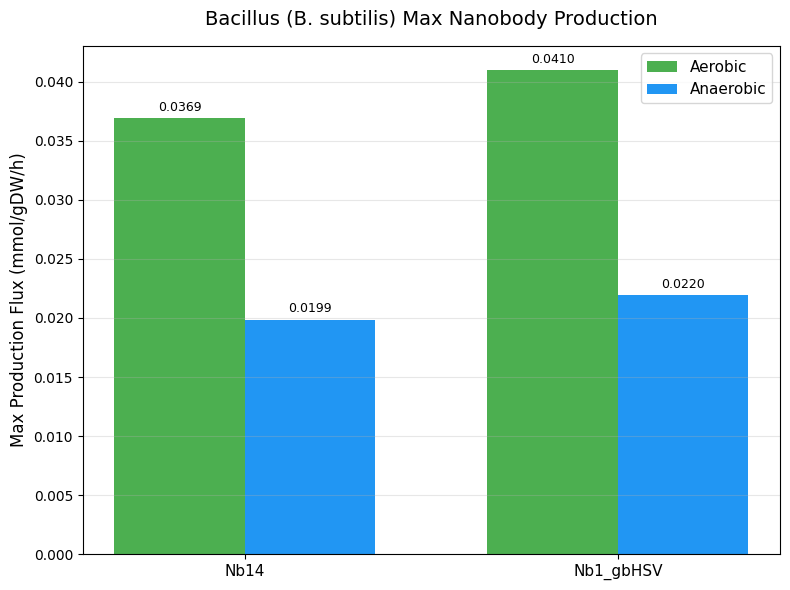

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the base bacillus model
# (Assumes 'bmodel' exists; falls back to 'model' if not)
bacillus_model = model.copy()
print(f"Glu {bacillus_model.reactions.EX_glc__D_e.bounds}")
print(f"O2 {bacillus_model.reactions.get_by_id("EX_o2_e").bounds}")
print(f"N {bacillus_model.reactions.get_by_id('EX_no3_e').bounds}")

# 2. Automatically find all Nanobody demand reactions
nb_rxns = [rxn.id for rxn in bacillus_model.reactions if 'NB' in rxn.id and 'DEMAND' in rxn.id]

if not nb_rxns:
    print("⚠️ No nanobody demand reactions found in the bacillus model.")
    print("Please make sure you have added them to 'bmodel' (or 'model') before running this cell.")
else:
    # 3. Create the anaerobic counterpart
    bacillus_anaerobic = bSubtilis_anaerobic_model(bacillus_model.copy())
    print(f"Glu {bacillus_anaerobic.reactions.get_by_id("EX_glc__D_e").bounds}")
    print(f"O2 {bacillus_anaerobic.reactions.get_by_id("EX_o2_e").bounds}")
    print(f"N {bacillus_anaerobic.reactions.get_by_id('EX_no3_e').bounds}")

    aerobic_fluxes = []
    anaerobic_fluxes = []

    print("Calculating max production for Bacillus (Aerobic vs Anaerobic)...")
    for rxn_id in nb_rxns:
        # Aerobic
        with bacillus_model as m_aero:
            m_aero.objective = rxn_id
            sol_aero = m_aero.optimize()
            val_aero = sol_aero.objective_value if sol_aero.status == 'optimal' and sol_aero.objective_value else 0.0
            aerobic_fluxes.append(val_aero)

        # Anaerobic
        with bacillus_anaerobic as m_anaero:
            m_anaero.objective = rxn_id
            sol_anaero = m_anaero.optimize()
            val_anaero = sol_anaero.objective_value if sol_anaero.status == 'optimal' and sol_anaero.objective_value else 0.0
            anaerobic_fluxes.append(val_anaero)

    # 4. Plot the results side-by-side
    x = np.arange(len(nb_rxns))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, aerobic_fluxes, width, label='Aerobic', color='#4CAF50')
    rects2 = ax.bar(x + width/2, anaerobic_fluxes, width, label='Anaerobic', color='#2196F3')

    # Mapping to correct the display names
    label_map = {
        'NB1': 'Nb1_gbHSV',
        'NB14': 'Nb14'
    }

    # Generate labels, falling back to the raw name if not in the dictionary
    labels = [label_map.get(rxn.replace('_DEMAND', ''), rxn.replace('_DEMAND', '')) for rxn in nb_rxns]

    ax.set_ylabel('Max Production Flux (mmol/gDW/h)', fontsize=12)
    ax.set_title('Bacillus (B. subtilis) Max Nanobody Production', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars with exact values
    for rect in rects1 + rects2:
        height = rect.get_height()
        if height > 1e-6:
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## Generating Targets for Knockouts & Overexpressions (Bacillus - Nb1)

### Knockouts

In [ ]:
model.objective = model.reactions.get_by_id('NB1_DEMAND')

In [ ]:
def analyze_nb1_flux_on_knockouts(model, threshold_x):
    """
    Performs single reaction knockouts and prints cases where NB1_DEMAND flux > threshold_x.
    """
    print(f"Scanning knockouts for NB1_DEMAND flux > {threshold_x}...")
    print("-" * 50)

    # Iterate through all reactions in the model
    for reaction in model.reactions:
        with model:
            reaction.knock_out()
            sol = model.optimize()

            if sol.status == 'optimal':
                nb1_flux = round(sol.fluxes['NB1_DEMAND'], 5)

                if nb1_flux > threshold_x:
                    print(f"Knockout: {reaction.id:15} | NB1 Flux: {nb1_flux:.5f}")
            else:
                # Infeasible or other issues usually imply 0 flux for the demand
                pass

# Example usage (uncomment and set x to run):
analyze_nb1_flux_on_knockouts(model, model.slim_optimize())

### Overexpressions

#### FSEOF Setup

In [ ]:
import os

# 1. Unzip the uploaded file
!rm -rf wwu-muenster-main
!unzip -q /content/wwu-muenster-main.zip -d /content/temp_fseof

# Handle the potential nested folder structure from GitHub/GitLab zips
extracted_folders = [f for f in os.listdir('/content/temp_fseof') if os.path.isdir(os.path.join('/content/temp_fseof', f))]
if extracted_folders:
    source_path = os.path.join('/content/temp_fseof', extracted_folders[0])
    !mv {source_path} /content/wwu-muenster-main
    !rm -rf /content/temp_fseof
else:
    !mv /content/temp_fseof /content/wwu-muenster-main

# 2. Move your model into the folder
if os.path.exists('/content/wwu-muenster-main'):
    !cp /content/yeast-GEM.xml /content/wwu-muenster-main/yeast-GEM.xml
    print('Software extracted and model successfully moved into wwu-muenster-main/')
else:
    print('Error: Extraction failed. Please ensure wwu-muenster-main.zip is in /content/')

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Software extracted and model successfully moved into wwu-muenster-main/


In [ ]:
# 3. Install requirements
import os
if os.path.exists('/content/wwu-muenster-main'):
    %cd /content/wwu-muenster-main
    !pip install cobra pandas openpyxl numpy -q
    if os.path.exists('requirements.txt'):
        !pip install -r requirements.txt -q
    print('Dependencies installed.')
else:
    print('Directory /content/wwu-muenster-main not found.')

/content/wwu-muenster-main
Dependencies installed.


#### Run FSEOF


In [ ]:
# Export the Model
cobra.io.write_sbml_model(model, "bacillus-GEM-NB1.xml")

In [ ]:
import cobra
import os

# 1. Aggressive Cleanup of Model for SBML Compliance
# Fix compartment IDs and metadata
new_compartments = {}
for c_id, c_name in model.compartments.items():
    # Ensure ID is not empty and follows SBML SId rules
    clean_id = c_id if c_id and c_id != '' else 'c'
    new_compartments[clean_id] = c_name if c_name else 'Cytosol'
model.compartments = new_compartments

# Ensure all metabolites have a valid SId and compartment
for met in model.metabolites:
    if not met.compartment or met.compartment == '':
        met.compartment = 'c'
    # Replace invalid characters in IDs
    met.id = met.id.replace('-', '_').replace(' ', '_')

# Ensure all reactions have a valid SId
for rxn in model.reactions:
    if not rxn.id or rxn.id == '' or ' ' in rxn.id or '-' in rxn.id:
        new_id = rxn.id.replace(' ', '_').replace('-', '_') if rxn.id else f'R_{id(rxn)}'
        rxn.id = new_id

# Ensure all genes have a valid SId
for gene in model.genes:
    if not gene.id or gene.id == '' or ' ' in gene.id or '-' in gene.id:
        new_id = gene.id.replace(' ', '_').replace('-', '_') if gene.id else f'G_{id(gene)}'
        gene.id = new_id

# 2. Setup Solver and Export
model.solver = 'glpk'
%cd /content/wwu-muenster-main
path_to_xml = "bacillus_final_fseof.xml"
cobra.io.write_sbml_model(model, path_to_xml)

print("Running FSEOF for Bacillus (Target: NB1_DEMAND, Biomass: bio00006)...")
# We increase steps to 10 to provide more points for curve_fit to converge
!python run_FSEOF.py {path_to_xml} bio00006 NB1_DEMAND

/content/wwu-muenster-main
Running FSEOF for Bacillus (Target: NB1_DEMAND, Biomass: bio00006)...
'' is not a valid SBML 'SId'.
/content/wwu-muenster-main/FSEOF.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f, enforcedFluxes, y)


In [ ]:
import pandas as pd
import os

# Load the results generated by FSEOF for Bacillus NB14
results_path = '/content/wwu-muenster-main/AmplificationTargets_NB1_DEMAND.xlsx'
if os.path.exists(results_path):
    # Re-loading the model used in the previous cell to ensure metadata is synced
    df_targets = pd.read_excel(results_path)

    # Cleanup the dataframe column names
    if 'Unnamed: 0' in df_targets.columns:
        df_targets.rename(columns={'Unnamed: 0': 'reaction_id'}, inplace=True)

    # Display the top 20 targets sorted by the slope (q_slope)
    # Higher positive slopes indicate stronger candidates for overexpression
    print("Top Amplification Targets for NB1 Production in Bacillus:")
    display_cols = ['reaction_id', 'q_slope']
    if 'reaction_string' in df_targets.columns:
        display_cols.append('reaction_string')

    display(df_targets.sort_values(by='q_slope', ascending=False).head(20)[display_cols])
else:
    print(f'Results file not found at {results_path}. Please verify if the FSEOF script completed successfully.')

Top Amplification Targets for NB1 Production in Bacillus:


,reaction_id,q_slope
1256,CO2t,528.542857
1255,NH4t,344.771410
1,EX_o2_e,308.199802
1142,PIt7,250.828647
2,EX_pi_e,233.214067
318,SUCOAS,164.200066
321,OCOAT1,118.028505
284,GLUDxi,108.885668
436,TPI,79.628592
535,PGM,56.771418


In [ ]:
# Now we need to filter the overexpression candidates to remove any exchange reactions or non-changeable ones like ATPM and the original nanobody demand reactions